In [2]:
#imports
%load_ext autoreload
%autoreload 2
%matplotlib widget
# import mkl
# mkl.set_num_threads(10)
import matplotlib
from natsort import natsorted
#necessary for plotly interactivity. dont ask me why
matplotlib.use('nbagg')
import numpy as np
import scipy as sp 
import matplotlib.pyplot as plt
#from mpl_toolkits.mplot3d import Axes3D
#from scipy import special
from random import gauss
#import hdf5storage
import h5py
import timeit
#from numba import jit
#from sympy.solvers.solveset import nonlinsolve
#from sympy.core.symbol import symbols
#from sympy import exp
from scipy import stats, io, sparse
import os
import sys
import glob
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from core.analysis import *
from core.simulation import *
import similaritymeasures as sm
sp.__version__

'1.17.1'

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 8})
plt.rcParams.update({'pdf.fonttype':42})
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
sjnr = '100307'#'154532'#'153732'#'102816' #'100307'#'133019'# 149741

# Load previously constructed connectome

In [5]:
output_suffix = ''#'_no_subcortex'#

is_cortical_vertex = ~np.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/noncortical_vertex_mask.npz")["is_noncortical"]

eigenvectors = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/eigenvectors{output_suffix}.npy')
eigenvalues = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/eigenvalues{output_suffix}.npy')

In [6]:
eigenvectors.shape

(20741, 20741)

In [7]:
#Set parameters and bounds for minimization algorithms

Graph_Kernel='Damped Wave'

aEE, bnds_aEE = 140, (0,1e3)
aIE, bnds_aIE = 155, (0,1e3)
aEI, bnds_aEI = 165, (0,1e3)
aII, bnds_aII = 140, (0,1e3)
dE, bnds_dE = 2, (0,1e3)
dI, bnds_dI = 2, (0,1e3)
P, bnds_P = 0, (-1e3,1e3)
Q, bnds_Q = 0, (-1e3,1e3)
sEE, bnds_sEE = 6, (0,1e3)
sIE, bnds_sIE = 10, (0,1e3)
sEI, bnds_sEI = 10, (0,1e3)
sII, bnds_sII = 50, (0,1e3)
#D, bnds_D = 1, (0.1,10)             #unchanged
tE, bnds_tE = 1, (0,1e3)          
tI, bnds_tI = 1, (0,1e3)          
#snE, bnds_snE = 1, (1,10)        #unchanged
#snI, bnds_snI = 1, (1,10)         #unchanged

initial_guess=[aEE,aIE,aEI,aII,dE,dI,P,Q,sEE,sIE,sEI,sII,tE,tI]#,snE])#,snI]) 
bnds=[bnds_aEE,bnds_aIE,bnds_aEI,bnds_aII,bnds_dE,bnds_dI,bnds_P,bnds_Q,bnds_sEE,bnds_sIE,bnds_sEI,bnds_sII,bnds_tE,bnds_tI]#,bnds_snE]#,bnds_snI]


if Graph_Kernel == 'Damped Wave':
    aDW_EE, bnds_aDW_EE = 0, (0,1e3)
    aDW_IE, bnds_aDW_IE = 0, (0,1e3)
    aDW_EI, bnds_aDW_EI = 0, (0,1e3)
    aDW_II, bnds_aDW_II = 0, (0,1e3)
    bDW_EE, bnds_bDW_EE = 0, (0,1e3)
    bDW_IE, bnds_bDW_IE = 0, (0,1e3)
    bDW_EI, bnds_bDW_EI = 0, (0,1e3)
    bDW_II, bnds_bDW_II = 0, (0,1e3)
    cDW_EE, bnds_cDW_EE = 0, (0,1e3)
    cDW_IE, bnds_cDW_IE = 0, (0,1e3)
    cDW_EI, bnds_cDW_EI = 0, (0,1e3)
    cDW_II, bnds_cDW_II = 0, (0,1e3)
    initial_guess += [aDW_EE,aDW_IE,aDW_EI,aDW_II,bDW_EE,bDW_IE,bDW_EI,bDW_II,cDW_EE, cDW_IE, cDW_EI, cDW_II]
    bnds += [bnds_aDW_EE,bnds_aDW_IE,bnds_aDW_EI,bnds_aDW_II,bnds_bDW_EE,bnds_bDW_IE,bnds_bDW_EI,bnds_bDW_II,bnds_cDW_EE,bnds_cDW_IE,bnds_cDW_EI,bnds_cDW_II]

In [8]:
import numpy as np
first_k=1
last_k=10000
#zero mean and no global signal

bins = np.unique(np.logspace(np.log10(first_k), np.log10(last_k), num=300, dtype=int))[:-1]
bins_positions = np.array([elem.mean() for elem in np.array_split(np.arange(first_k,last_k), bins)])
def median_binning(data,bins):
    return np.array([np.median(elem) for elem in np.array_split(data, bins)])

empirical_SPS_runs = []
for dir in ['RL','LR']:
    for run in ['1','2']:
        timecourse = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/MNINonLinear/Results/surface_fmri_timeseries_rfMRI_REST{run}_{dir}.npy')#[is_cortical_vertex]

        tc_nomean = timecourse-timecourse.mean(1)[...,np.newaxis]
        coeffs = np.dot(eigenvectors.T,(tc_nomean-tc_nomean.mean(0)[np.newaxis,...]))

        empirical_SPS_runs.append((np.abs(coeffs)**2).mean(1)[first_k:last_k])

empirical_SPS = np.mean(empirical_SPS_runs,axis=0)

In [9]:

bins = np.unique(np.logspace(np.log10(first_k), np.log10(last_k), num=300, dtype=int))[:-1]
binned_SPS = np.array([np.median(elem) for elem in np.array_split(empirical_SPS, bins)])
binned_SPS_points = np.array([elem.mean() for elem in np.array_split(np.arange(first_k,last_k), bins)])
binned_SPS_err = np.array([sp.stats.sem(elem) for elem in np.array_split(empirical_SPS, bins)])
len(bins)

217

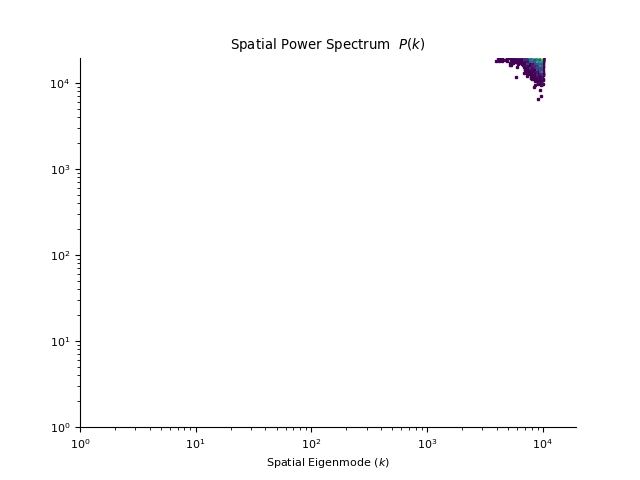

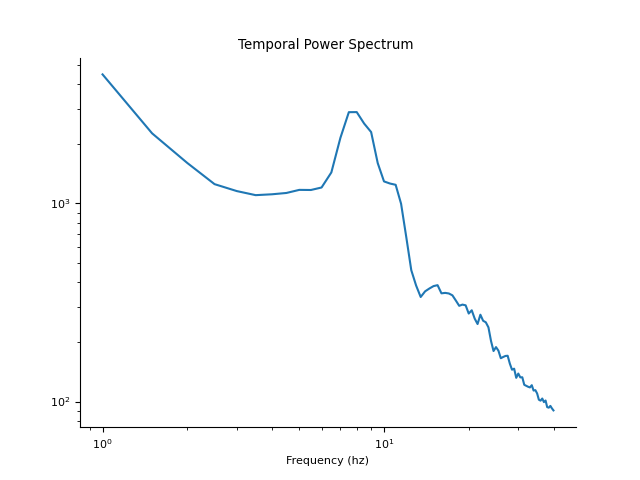

In [10]:
%matplotlib widget
import matplotlib.pyplot as plt

plt.figure()
plt.yscale('log')
plt.xscale('log')
plt.title("Spatial Power Spectrum  $P(k)$")
plt.xlabel("Spatial Eigenmode ($k$)")
#plt.errorbar(x=np.arange(len(empirical_SPS)), y=empirical_SPS, yerr=0, fmt='ks', markersize=1, zorder=1)
plt.errorbar(x=binned_SPS_points, y=binned_SPS, yerr=binned_SPS_err, zorder=2, fmt='yo',markersize=3)

plt.loglog(np.arange(first_k, last_k), empirical_SPS, marker='s', linestyle='', markersize=2, zorder=0, color=[0.267004, 0.004874, 0.329415, 1.])
plot_bins = np.unique(np.logspace(0, np.log10(20000), num=300, dtype=int))[:-1]
y_bins = np.unique(np.logspace(0, np.log10(len(eigenvalues)), num=200, dtype=int))[:-1]
plt.hist2d(np.arange(first_k, last_k), empirical_SPS, (plot_bins, y_bins), cmap='viridis',zorder=1,cmin=2)

fit_to_median=True
if fit_to_median:
    True_Spatial_Spectrum = binned_SPS
    Bins=bins
else:
    True_Spatial_Spectrum = empirical_SPS
    Bins=None
        
LSA=True
Visual=False
SaveFiles=False
FilePath=' '

Min_omega=None
Max_omega=None
Delta_omega=None


fig2 = plt.figure()
ax = fig2.add_subplot(111)
ax.set_title("Temporal Power Spectrum ")
ax.set_xlabel("Frequency (hz)")

meg_hcp_ps_1 = sp.io.loadmat(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/MEG/Restin/powavg/{sjnr}_MEG_3-Restin_powavg.mat')
meg_hcp_ps_2 = sp.io.loadmat(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/MEG/Restin/powavg/{sjnr}_MEG_4-Restin_powavg.mat')
meg_hcp_ps_3 = sp.io.loadmat(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/MEG/Restin/powavg/{sjnr}_MEG_5-Restin_powavg.mat')

meg_hcp_ps_avg = (meg_hcp_ps_1['freq'][0][0][3][0]+meg_hcp_ps_2['freq'][0][0][3][0]+meg_hcp_ps_3['freq'][0][0][3][0])/3.0

meg_hcp_freqs = (meg_hcp_ps_1['freq'][0][0][2][0]>0.99) & (meg_hcp_ps_1['freq'][0][0][2][0]<40)

omegas = meg_hcp_ps_1['freq'][0][0][2][0][meg_hcp_freqs]*2*np.pi

True_Temporal_Spectrum = (2.5*meg_hcp_ps_avg[meg_hcp_freqs]* 10 **30).astype(np.float32)
ax.loglog(meg_hcp_ps_1['freq'][0][0][2][0][meg_hcp_freqs],2.5*meg_hcp_ps_avg[meg_hcp_freqs]* 10 **30)


# Fitting

In [ ]:
np.set_printoptions(precision=4)


initial_guess=better_result['x']
#initial_guess[14]*=1000


#result['x']#np.load('de_fitting_23_subc_dti50.npy')#better_result['x']#better_result['x']

#initial_guess[14:18] *= 10
#change none to True_Spatial_Spectrum if want to fit to both
Args = (eigenvalues, Graph_Kernel, True_Temporal_Spectrum, Min_omega, Max_omega, Delta_omega, omegas,
        True_Spatial_Spectrum/1000, first_k, last_k, Bins, LSA, Visual, SaveFiles, FilePath, 20, True, False)


result = sp.optimize.minimize(Full_Analysis, initial_guess, args=Args,
                              method='Nelder-Mead', 
                              bounds=bnds,
                              #constraints=constraints,
                              tol=1e-8,
                              options={#'ftol':1e-10,
                                      # 'xtol':1e-16,
                                     #  'maxiter': 1000,
                                #  'adaptive':True,
                                   #   'maxls':200,
                                       'disp':True})

In [ ]:
Args = (eigenvalues, Graph_Kernel, True_Temporal_Spectrum, Min_omega, Max_omega, Delta_omega, omegas,
        True_Spatial_Spectrum/1000, first_k, last_k, Bins, LSA, Visual, SaveFiles, FilePath, 20, True, False)
Full_Analysis(better_result['x'], *Args)

In [ ]:
############################
#more complicated fitting attempt with basinhopping stochastic minimization
#to obtain good results in sensible amounts of time, playing with minimization parameters is required
#the relevant parameter are again tolerance and maxiter, similarly to above (which affect the local minimization loop)
#but also niter and stepsize. these specify how many local minimizations we wish to carry out, 
#and the size of the basin-hopping random step inbetween local minimizations

plt.close('all')
#Init=np.stack((new_initial_guess,new_initial_guess,new_initial_guess,new_initial_guess,new_initial_guess))
Init =np.stack((np.array([6.8811e+02, 7.9165e+01, 9.9711e+02, 1.2211e+02, 1.0051e+02, 8.5666e+00,
  4.3092e+00, 6.9957e+00, 4.6705e-05, 1.4132e-03, 1.8037e-02, 2.3725e-01,
  4.2467e-01, 3.5548e-01,10**3,10**3,10**3,10**3,10,10,10,10]),
                np.array([2.1864e+02, 1.2605e+02, 1.8265e+02, 9.8375e+01, 3.9675e+01,
        6.3733e-01, 7.3077e+00, 9.4213e-01, 7.1691e-03, 4.1517e-03,
        8.2703e-02, 9.5257e-02, 2.2306e-01, 1.9062e-01, 3.9409e-08,
        3.8537e-05, 1.6828e-04, 3.0538e-04, 1.9185e+00, 9.3723e-01,
        1.7785e+00, 8.9270e-01]),
                np.array([7.1591e+02, 3.1259e+02, 2.8662e+02, 1.6442e+02, 2.6423e+01,
       1.2825e+00, 2.1835e+01, 8.7888e+00, 1.7436e-03, 1.0713e-03,
       7.9180e-02, 1.0382e-01, 1.9880e-01, 2.2459e-01, 9.7932e-01,
       8.6580e-01, 1.0692e+00, 7.9494e-01, 1.0150e-02, 1.1836e-01,
       5.4146e-03, 1.0648e-02]),
                np.array([2.1864e+02, 1.2605e+02, 1.8265e+02, 9.8375e+01, 3.9675e+01,
        6.3733e-01, 7.3077e+00, 9.4213e-01, 7.1691e-03, 4.1517e-03,
        8.2703e-02, 9.5257e-02, 2.2306e-01, 1.9062e-01, 3.9409e-08,
        3.8537e-05, 1.6828e-04, 3.0538e-04, 1.9185e+00, 9.3723e-01,
        1.7785e+00, 8.9270e-01]),
                np.array([2.18640000e+02, 1.77321423e+02, 2.97178667e+02, 9.83750000e+01,
       2.63635016e+01, 6.37330000e-01, 7.30770000e+00, 9.42130000e-01,
       3.04537982e-03, 4.15170000e-03, 1.06443266e-01, 9.52570000e-02,
       2.23060000e-01, 1.81494557e-01, 3.94089739e-08, 3.85370000e-05,
       1.22411168e+02, 3.05380000e-04, 1.91850000e+00, 2.64375950e+00,
       1.24421530e-06, 8.92700000e-01]),
                np.array([2.41362341e+02, 1.87465571e+02, 3.06359129e+02, 9.83750000e+01,
       2.48031935e+01, 6.37329991e-01, 7.53833099e+00, 9.42130150e-01,
       2.29619993e-03, 4.15156353e-03, 9.20363949e-02, 1.25773356e+01,
       1.67598599e-01, 2.21462762e-01, 6.68549170e-07, 3.77186998e-05,
       3.68790813e+01, 4.29250127e+02, 1.91849997e+00, 1.53394297e-10,
       9.99999995e+02, 2.48366338e+01]),
                np.array([7.1591e+02, 3.1259e+02, 2.8662e+02, 1.6442e+02, 2.6423e+01,
       1.2825e+00, 2.1835e+01, 8.7888e+00, 1.7436e-03, 1.0713e-03,
       7.9180e-02, 1.0382e-01, 1.9880e-01, 2.2459e-01, 9.7932e-01,
       8.6580e-01, 1.0692e+00, 7.9494e-01, 1.0150e-02, 1.1836e-01,
       5.4146e-03, 1.0648e-02]),
                np.array([6.88112381e+02, 7.85722370e+01, 9.97105458e+02, 1.22114834e+02,
  1.00095980e+02 ,8.71706788e+00 ,4.45444506e+00, 6.72211504e+00,
  2.69548038e-03 ,1.94174600e-03, 1.55065050e-02, 2.22532549e-01,
  7.02896805e-01, 2.03388273e-01,1e-8,1e-8,1e-8,1e-8,1,1,1,1]),
               np.array([1.48665460e+02, 2.19057310e+02 ,2.62024638e+02 ,1.61437274e+02,
  2.71802361e+01, 1.24033047e+00, 2.23516416e+01 ,8.45022796e+00,
  1.61138979e-02, 2.02249219e-03 ,6.69814861e-02 ,9.14930664e-02,
  2.02440304e-01, 2.34608894e-01,1e-4,1e-4,1e-4,1e-4,1,1,1,1])
                ,np.array([2.41362341e+02, 1.87465571e+02, 3.06359129e+02, 9.83750000e+01,
       2.48031935e+01, 6.37329991e-01, 7.53833099e+00, 9.42130150e-01,
       2.29619993e-03, 4.15156353e-03, 9.20363949e-02, 1.25773356e+01,
       1.67598599e-01, 2.21462762e-01, 6.68549170e-07, 3.77186998e-05,
       3.68790813e+01, 4.29250127e+02, 1.91849997e+00, 1.53394297e-10,
       9.99999995e+02, 2.48366338e+01]),
                np.array([1.48665460e+02, 2.19057310e+02 ,2.62024638e+02 ,1.61437274e+02,
  2.71802361e+01, 1.24033047e+00, 2.23516416e+01 ,8.45022796e+00,
  1.61138979e-02, 2.02249219e-03 ,6.69814861e-02 ,9.14930664e-02,
  2.02440304e-01, 2.34608894e-01,1,1,1,1,0,0,0,0]),
                np.array([1.48665460e+02, 2.19057310e+02 ,2.62024638e+02 ,1.61437274e+02,
  2.71802361e+01, 1.24033047e+00, 2.23516416e+01 ,8.45022796e+00,
  1.61138979e-02, 2.02249219e-03 ,6.69814861e-02 ,9.14930664e-02,
  2.02440304e-01, 2.34608894e-01,1,1,1,1,0,0,0,0]),
               np.array([2.41362341e+02, 1.87465571e+02, 3.07070611e+02, 9.83020065e+01,
       2.50482813e+01, 6.42417383e-01, 7.53833099e+00, 9.42130411e-01,
       2.29472860e-03, 4.38074525e-03, 9.66418938e-02, 1.25773356e+01,
       1.67598599e-01, 2.20469165e-01, 6.90292552e-07, 3.77694684e-05,
       3.52815567e+01, 4.28978324e+02, 1.90121591e+00, 1.53420388e-10,
       9.99999995e+02, 2.48366338e+01]),
               np.array([2.41362341e+02, 1.91972736e+02, 3.43129169e+02, 9.81822854e+01,
       1.83207981e+01, 6.81612724e-01, 7.53902321e+00, 9.42131958e-01,
       2.27827826e-03, 4.54506746e-03, 9.91236679e-02, 1.25773356e+01,
       1.67598599e-01, 1.95175950e-01, 9.02941281e-07, 3.89303902e-05,
       3.47269915e+01, 4.28930846e+02, 1.32830186e+00, 1.53420388e-10,
       9.98838348e+02, 2.57433636e+01]),
               np.array([2.41362341e+02, 1.91972736e+02, 3.43129169e+02, 9.81822854e+01,
       1.83207981e+01, 6.81612724e-01, 7.53902321e+00, 9.42131958e-01,
       2.27827826e-03, 4.54506746e-03, 9.91236679e-02, 1.25773356e+01,
       1.67598599e-01, 1.95175950e-01, 9.02941281e-07, 3.89303902e-05,
       3.47269915e+01, 4.28930846e+02, 1.32830186e+00, 1.53420388e-10,
       9.98838348e+02, 2.57433636e+01]),
               np.array([2.31433810e+02, 1.90466280e+02, 3.65867090e+02, 9.83488441e+01,
       1.57541270e+01, 1.06325753e+00, 6.83325920e+00, 9.42128706e-01,
       1.92504060e-03, 4.24971198e-03, 9.36492001e-02, 1.25773356e+01,
       1.48446722e-01, 3.28173163e-01, 1.71043587e-06, 1.02027693e-04,
       1.47802800e+02, 4.28158241e+02, 6.11200743e-02, 4.06048066e-01,
       9.73777791e+02, 2.74980421e+01]),
               np.array([2.31539428e+02, 1.90466280e+02, 3.66655721e+02, 9.83556269e+01,
       1.57541270e+01, 1.06415552e+00, 6.83325920e+00, 9.42043599e-01,
       1.92504060e-03, 4.24870488e-03, 9.36492001e-02, 1.25773356e+01,
       1.48446722e-01, 3.27362408e-01, 1.71043587e-06, 1.03542890e-04,
       1.48506875e+02, 4.28158241e+02, 8.34346063e-02, 1.53420388e-10,
       5.86913552e+02, 2.77827962e+01]),
               np.array([3.4504e+02, 1.8893e+02, 3.0881e+02, 9.0579e+01, 2.0876e+01,
       5.8554e-01, 7.2718e+00, 9.4413e-01, 2.2475e-03, 4.6180e-03,
       9.5867e-02, 4.4390e+02, 1.4111e-01, 1.5644e-01, 1.4847e-06,
       9.7867e-05, 7.2554e+01, 6.0210e+02, 3.2340e-01, 7.2727e-03,
       6.0175e+02, 2.7397e+02]),
                np.array([2.0711e+02, 1.8978e+02, 5.7584e+01, 8.5774e+01, 8.8681e+00,
       4.3599e-01, 1.0158e+01, 2.7923e+00, 1.8281e-03, 1.7785e-03,
       3.0333e-03, 9.9979e-03, 1.3090e-02, 2.0949e-01, 8.4589e-07,
       9.2430e+01, 5.0643e+02, 3.0111e-03, 2.7026e-07, 6.3554e+02,
       9.0269e+02, 5.0262e-03]),
                np.array([2.0655e+02, 1.8873e+02, 5.6840e+01, 8.5665e+01, 8.3016e+00,
       4.1574e-01, 1.0003e+01, 2.7247e+00, 1.8148e-03, 1.8600e-03,
       3.1506e-03, 9.8988e-03, 1.5143e-02, 2.4088e-01, 8.3493e-07,
       9.8706e+01, 5.4141e+02, 2.9517e-03, 2.8064e-07, 6.0304e+02,
       8.5795e+02, 5.0528e-03]),
                np.array([2.0627e+02, 1.8869e+02, 5.6852e+01, 8.5674e+01, 8.3170e+00,
       4.1599e-01, 1.0001e+01, 2.7256e+00, 1.8148e-03, 1.8592e-03,
       3.1494e-03, 9.9003e-03, 1.4972e-02, 2.3195e-01, 8.3521e-07,
       9.8663e+01, 5.4128e+02, 2.9514e-03, 2.8051e-07, 6.0317e+02,
       8.5771e+02, 5.0531e-03]),
                np.array([2.0727e+02, 1.8831e+02, 5.5119e+01, 8.5348e+01, 8.2160e+00,
       4.1431e-01, 9.9876e+00, 2.7224e+00, 1.8124e-03, 1.8619e-03,
       3.1507e-03, 9.9035e-03, 1.7363e-02, 2.5101e-01, 8.2931e-07,
       9.8833e+01, 5.4557e+02, 2.9572e-03, 2.7870e-07, 6.1514e+02,
       8.6779e+02, 4.9837e-03])))



Init_2 =np.stack((#better_result['x'], better_result['x'], #np.load(f'de_fitting_hcpmeg_subc_dti50_{sjnr}_2.npy'), np.load(f'de_fitting_hcpmeg_subc_dti50_{sjnr}_2.npy'),
#     np.load(f'de_fitting_hcpmeg_subc_dti50_158136_10.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_158136_10.npy'),
#     np.load(f'de_fitting_hcpmeg_subc_dti50_158136_9.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_158136_9.npy'),
#     np.load(f'de_fitting_hcpmeg_subc_dti50_158136_8.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_158136_8.npy'),
#                   np.load(f'de_fitting_hcpmeg_subc_dti50_158136_7.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_158136_7.npy'),
                        np.load(f'de_fitting_hcpmeg_subc_dti50_154532_1.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_154532_1.npy'),
                        np.load(f'de_fitting_hcpmeg_subc_dti50_153732_2.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_153732_2.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_100307_1.npy'), np.load(f'de_fitting_hcpmeg_subc_dti50_100307_1.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_102816_9.npy'), np.load(f'de_fitting_hcpmeg_subc_dti50_102816_9.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_s102816_8.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_s102816_8.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_133019_2.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_2.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_133019_1.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_1.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_133019_11.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_11.npy'),
                   np.load(f'de_fitting_hcpmeg_subc_dti50_133019_13.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_13.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_133019_12.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_12.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_133019_10.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_10.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_133019_9.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_9.npy'),
                  np.load(f'de_fitting_hcpmeg_subc_dti50_133019_8.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_8.npy'),
                   np.load(f'de_fitting_hcpmeg_subc_dti50_133019_6.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_7.npy'),
                   np.load(f'de_fitting_hcpmeg_subc_dti50_133019_6.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_7.npy'),
                   np.load(f'de_fitting_hcpmeg_subc_dti50_133019_3.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_3.npy'),
                   np.load(f'de_fitting_hcpmeg_subc_dti50_s102816_4.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_s102816_4.npy'),
                   np.load(f'de_fitting_hcpmeg_subc_dti50_133019_5.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_5.npy'),
                np.load(f'de_fitting_hcpmeg_subc_dti50_s102816_7.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_s102816_7.npy'),
                  np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/de_fitting_hcpmeg_subc_dti50_4.npy'),np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/de_fitting_hcpmeg_subc_dti50_4.npy'),
                  np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/de_fitting_hcpmeg_subc_dti50_4.npy'),np.load('/Users/marcoaqil/Desktop/miami_mac/Downloads/de_fitting_hcpmeg_subc_dti50_4.npy'),
        np.array([2.1864e+02, 1.2605e+02, 1.8265e+02, 9.8375e+01, 3.9675e+01,
        6.3733e-01, 7.3077e+00, 9.4213e-01, 7.1691e-03, 4.1517e-03,
        8.2703e-02, 9.5257e-02, 2.2306e-01, 1.9062e-01, 3.9409e-08,
        3.8537e-05, 1.6828e-04, 3.0538e-04, 1.9185e+00, 9.3723e-01,
        1.7785e+00, 8.9270e-01]),
                np.array([7.1591e+02, 3.1259e+02, 2.8662e+02, 1.6442e+02, 2.6423e+01,
       1.2825e+00, 2.1835e+01, 8.7888e+00, 1.7436e-03, 1.0713e-03,
       7.9180e-02, 1.0382e-01, 1.9880e-01, 2.2459e-01, 9.7932e-01,
       8.6580e-01, 1.0692e+00, 7.9494e-01, 1.0150e-02, 1.1836e-01,
       5.4146e-03, 1.0648e-02]),
               np.array([6.8811e+02, 7.9165e+01, 9.9711e+02, 1.2211e+02, 1.0051e+02, 8.5666e+00,
  4.3092e+00, 6.9957e+00, 4.6705e-05, 1.4132e-03, 1.8037e-02, 2.3725e-01,
  4.2467e-01, 3.5548e-01,10**3,10**3,10**3,10**3,10,10,10,10])))

disp_print = False
multi_state = False

Args = (eigenvalues, Graph_Kernel, True_Temporal_Spectrum, Min_omega, Max_omega, Delta_omega, omegas,
        True_Spatial_Spectrum/1000, first_k, last_k, Bins, LSA, Visual, SaveFiles, FilePath, 0.0, disp_print, multi_state)

Init_mult = np.tile(Init_2,(5,1))

Init_mult = np.concatenate((Init_mult,Init))

Init_mult_rand = np.concatenate((Init_mult,np.random.rand(len(Init_mult),4)),axis=1)

Init_mult_zero = np.concatenate((Init_mult,np.zeros((len(Init_mult),4))),axis=1)

#Init_mult = np.concatenate(([better_result['x']],Init_mult_rand,Init_mult_zero))

Init_mult = np.concatenate((Init_mult_rand,Init_mult_zero))

Init_mult = np.concatenate(([np.load(f'de_fitting_hcpmeg_subc_dti50_133019_18.npy'),np.load(f'de_fitting_hcpmeg_subc_dti50_133019_18.npy')], Init_mult))

#Init_mult = np.stack((better_result['x'],better_result['x']+np.random.rand()))


#Init='sobol' (bad)
#try with default strategy (doing)
#try higher 0.8 (doing 0.5)
#currently trying with full dti, subcortex, dti factor of 50 instead of 200
#allow intercept in linear scaling?
#change metric back to area between curves?
#allow combination with inhibitory spectrum

better_result = sp.optimize.differential_evolution(Full_Analysis, bounds=bnds, 
                                                 args=Args, tol=1e-6, disp=True, init=Init_mult, 
                                                 maxiter=500, polish=False, workers=14, recombination=0.8,
                                            #    strategy='rand1bin',
                                                mutation=(0.2,1.8))
# better_result = sp.optimize.shgo(Full_Analysis, bounds=bnds, 
#                                                  args=Args, options=dict(f_tol=1e-6, disp=True), workers=20
#                                              )

In [ ]:
import cma
import numpy as np
import multiprocessing as mp

disp_print = False
multi_state = False

Args = (
    eigenvalues, Graph_Kernel, True_Temporal_Spectrum,
    Min_omega, Max_omega, Delta_omega, omegas,
    True_Spatial_Spectrum / 1000,
    first_k, last_k, Bins, LSA, Visual,
    SaveFiles, FilePath, 0, disp_print, multi_state
)

def obj(x):
    return Full_Analysis(x, *Args)

known = [better_result['x']]

sigma0 = 0.01


opts = {
    "bounds": [np.array(bnds)[:, 0], np.array(bnds)[:, 1]],
    "tolx": 1e-8,
    "maxiter": 5000,
    "verb_disp": 1,
    "CMA_active": True,
    "popsize": 10 * len(bnds)#,
   # "CMA_elitist": True
}

es = cma.CMAEvolutionStrategy(better_result['x'], sigma0, opts)

# --- Parallel evaluation using 14 cores ---
with mp.get_context("fork").Pool(processes=14) as pool:
    while not es.stop():
        #es.inject([x0])
        solutions = es.ask()
        # Force x0 into the first generation
        if es.countiter % 20 == 0:
            solutions[:len(known)] = known
        fitness = pool.map(obj, solutions)
        es.tell(solutions, fitness)
        es.disp()

best_x = es.result.xbest
best_f = es.result.fbest


# Replot fit results

In [11]:
import glob
import re

# Find all matching files for this subject
pattern = f'de_fitting_hcpmeg_subc_dti50_{sjnr}_*.npy'
matching_files = glob.glob(pattern)

if matching_files:
    # Extract iteration numbers and find the maximum
    iterations = []
    for f in matching_files:
        match = re.search(rf'de_fitting_hcpmeg_subc_dti50_{sjnr}_(\d+)\.npy', f)
        if match:
            iterations.append((int(match.group(1)), f))
    
    # Get file with highest iteration number
    max_iter, max_file = max(iterations, key=lambda x: x[0])
    
    # Load the result
    better_result = dict(x=np.load(max_file))
    print(f"Loaded iteration {max_iter}: {max_file}")
else:
    print(f"No results found for subject {sjnr}")


Loaded iteration 1: de_fitting_hcpmeg_subc_dti50_100307_1.npy


In [14]:

    
print(Graph_Kernel)    
print(better_result['x'])    
np.set_printoptions(precision=8)

#better_result['x'][0]*=1.005

SStates, success = H_Simple_Steady_State(alpha_EE=better_result['x'][0], alpha_IE=better_result['x'][1], alpha_EI=better_result['x'][2], alpha_II=better_result['x'][3], 
                                         d_e=better_result['x'][4], d_i=better_result['x'][5], P=better_result['x'][6], Q=better_result['x'][7])
print(SStates)     
SSnr=0
# Best suitable steady state: 0, with Ess=0.003813 Iss=0.0522.                       
# Dist spatial: 1493, scale params: [6170.0315 1328.5838 4896.9869]                        
# Dist temporal: 2092, scale params: [  10.7089   -3.767  -318.5677]
sigma_noise=0#0.0000001

 
SStype, found_suitable, JacEigs = GraphWC_Jacobian_TrDet(Laplacian_eigenvalues=eigenvalues, Graph_Kernel=Graph_Kernel, Ess=SStates[0,SSnr], Iss=SStates[1,SSnr],
                                     alpha_EE=better_result['x'][0], alpha_IE=better_result['x'][1], alpha_EI=better_result['x'][2], alpha_II=better_result['x'][3], d_e=better_result['x'][4], d_i=better_result['x'][5], 
                                     sigma_EE=better_result['x'][8], sigma_IE=better_result['x'][9], sigma_EI=better_result['x'][10], sigma_II=better_result['x'][11],  
                                     D=1, tau_e=better_result['x'][12], tau_i=better_result['x'][13], 
                                    aDW_EE=better_result['x'][14],aDW_IE=better_result['x'][15], aDW_EI=better_result['x'][16], aDW_II=better_result['x'][17],
                                    bDW_EE=better_result['x'][18], bDW_IE=better_result['x'][19], bDW_EI=better_result['x'][20], bDW_II=better_result['x'][21],
                              #      cDW_EE=better_result['x'][22], cDW_IE=better_result['x'][23], cDW_EI=better_result['x'][24], cDW_II=better_result['x'][25],
                                                         
                                                         Visual=False)    
np.min(JacEigs.real)

Damped Wave
[1.97004109e+02 1.89555076e+02 6.66456817e+01 7.92814322e+01
 9.33753760e+00 2.55547786e-01 1.19514113e+01 2.49802005e+00
 1.79384096e-03 6.06381569e-02 4.42952021e-02 6.81315233e+02
 1.55357202e-02 3.02441909e-01 1.02279733e-06 2.96374152e+02
 2.98298638e+02 6.13542727e+02 2.41818340e-02 6.59474082e+02
 1.56295124e+02 5.05280000e-03]
[[0.00533573 0.08807127]
 [0.08414838 0.14649744]]


np.float64(-1188.3192544114643)

<>:105: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:112: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:105: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:112: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/cw/1v50jvlx7wzfdpd05sq5s9_w0000gn/T/ipykernel_89674/128958731.py:105: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax_jac_damp[0,sjidx].set_xlabel('-Re($\lambda_J$)')
/var/folders/cw/1v50jvlx7wzfdpd05sq5s9_w0000gn/T/ipykernel_89674/128958731.py:112: SyntaxWarning

Loaded iteration 1: de_fitting_hcpmeg_subc_dti50_100307_1.npy
Damped Wave
[1.97004109e+02 1.89555076e+02 6.66456817e+01 7.92814322e+01
 9.33753760e+00 2.55547786e-01 1.19514113e+01 2.49802005e+00
 1.79384096e-03 6.06381569e-02 4.42952021e-02 6.81315233e+02
 1.55357202e-02 3.02441909e-01 1.02279733e-06 2.96374152e+02
 2.98298638e+02 6.13542727e+02 2.41818340e-02 6.59474082e+02
 1.56295124e+02 5.05280000e-03]
[[0.00533573 0.08807127]
 [0.08414838 0.14649744]]
0.6066817333428889
538.4504871898262
Loaded iteration 9: de_fitting_hcpmeg_subc_dti50_102816_9.npy
Damped Wave
[2.46763820e+02 1.96808636e+02 6.24363551e+01 8.57146500e+01
 9.05261962e+00 4.98066056e-01 1.02268984e+01 2.78099497e+00
 2.85442161e-03 6.79111871e-02 8.50753884e-02 2.09865182e+00
 1.59736301e-02 2.66648852e-01 3.96271093e-06 3.84539860e-05
 7.13606423e+02 1.07355401e+02 6.10733045e-01 5.81510964e+02
 7.44435859e+02 5.08865206e+02]
[[0.00421873 0.01606499 0.11045579]
 [0.07364594 0.08110446 0.14287456]]
1.025465295077692

/Users/marcoaqil/miniforge3/envs/gnf_env/lib/python3.14/site-packages/ipympl/backend_nbagg.py:392: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')


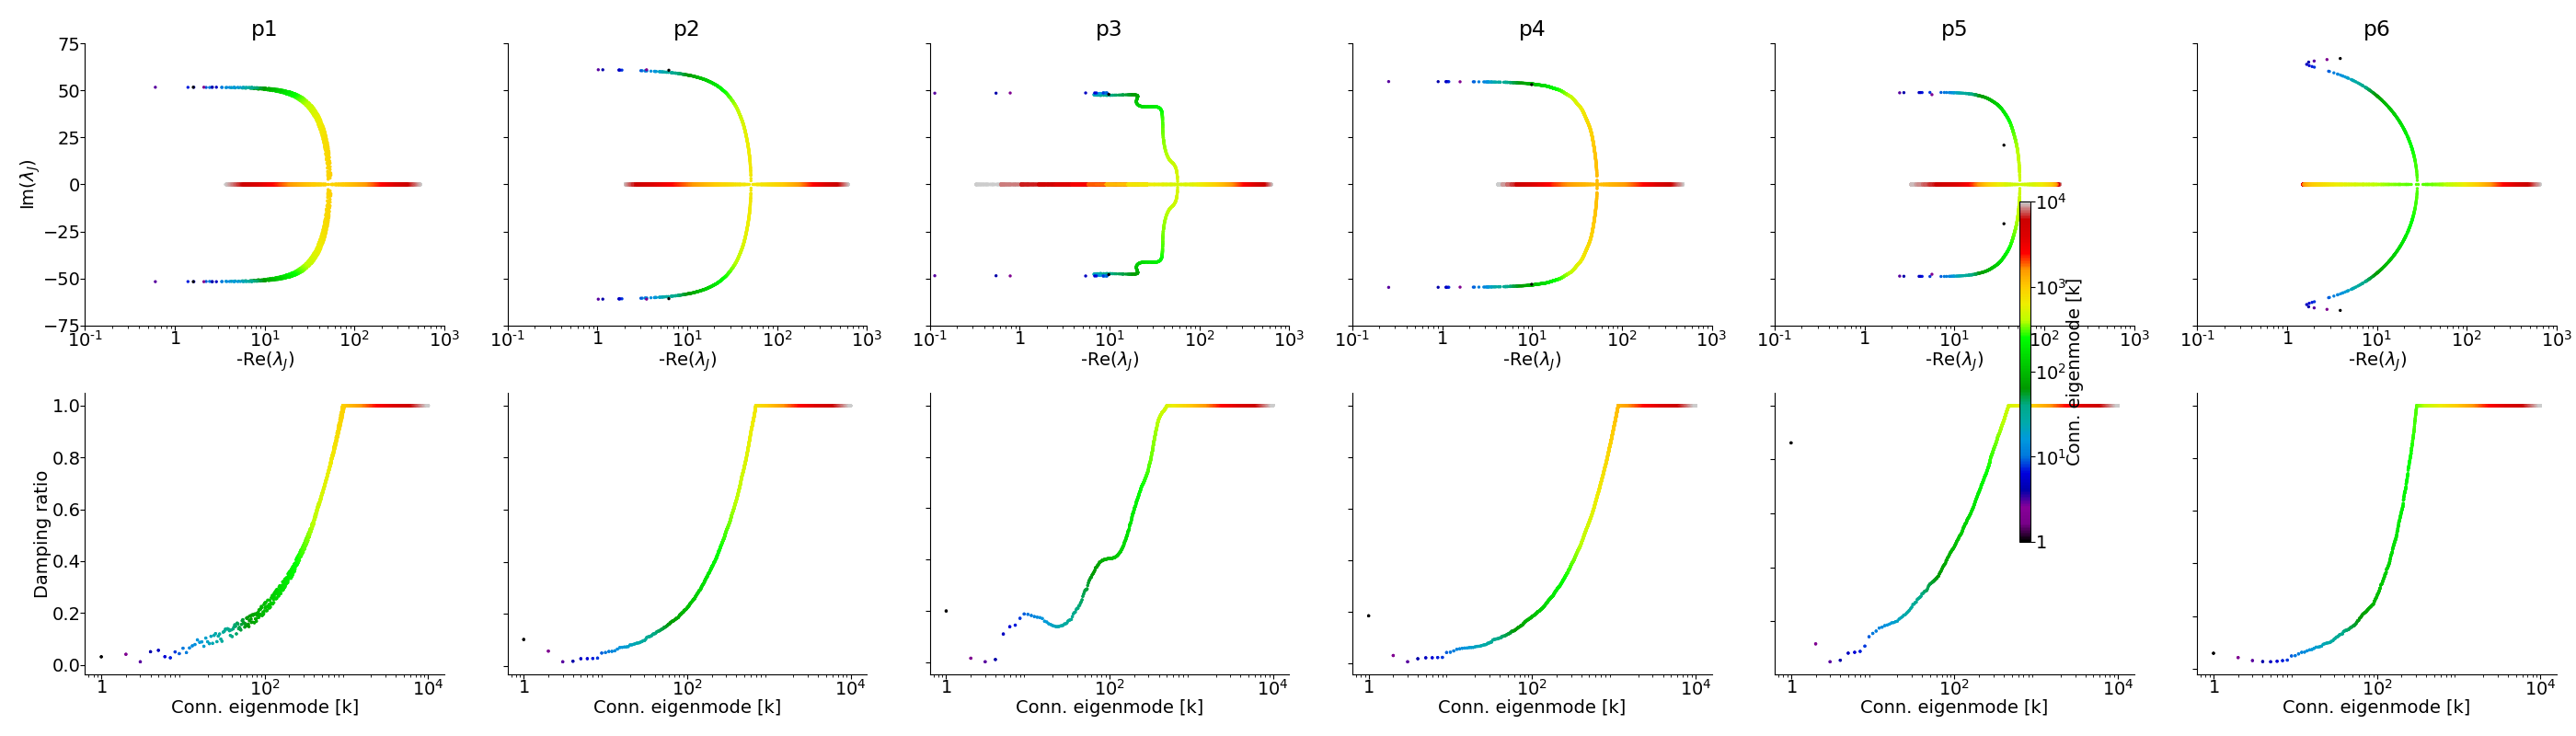

In [ ]:
import glob
import re
from matplotlib.ticker import FuncFormatter, LogLocator
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

plt.close('all')
plt.rcParams.update({
    'font.size': 14,
    'pdf.fonttype': 42,
    'figure.max_open_warning': 0,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.pad': 0,
    'ytick.major.pad': 0,
    'axes.labelpad': 0,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

def log_tick_formatter(value, position):
    exponent = int(np.round(np.log10(value)))
    if exponent == 0:
        return '$1$'
    if exponent < 0:
        return r'$10^{{\text{{-}}{}}}$'.format(abs(exponent))
    return r'$10^{{{}}}$'.format(exponent)

eigenmode_tick_locations = [1, 100, 10000]

# log10 color range: 0 to 4 (i.e. eigenmode index 1 to 10^4)
colormap_log10_min = 0
colormap_log10_max = 4

f_jac_damp, ax_jac_damp = plt.subplots(2, 6, figsize=(28, 8), tight_layout=True)

for sjidx, sjnr in enumerate(['100307', '102816', '133019', '149741', '153732', '154532']):
    # Find all matching files for this subject
    pattern = f'de_fitting_hcpmeg_subc_dti50_{sjnr}_*.npy'
    matching_files = glob.glob(pattern)

    if matching_files:
        # Extract iteration numbers and find the maximum
        iterations = []
        for f in matching_files:
            match = re.search(rf'de_fitting_hcpmeg_subc_dti50_{sjnr}_(\d+)\.npy', f)
            if match:
                iterations.append((int(match.group(1)), f))
        
        # Get file with highest iteration number
        max_iter, max_file = max(iterations, key=lambda x: x[0])
        
        # Load the result
        better_result = dict(x=np.load(max_file))
        print(f"Loaded iteration {max_iter}: {max_file}")
    else:
        print(f"No results found for subject {sjnr}")

    Graph_Kernel='Damped Wave'
        
    print(Graph_Kernel)    
    print(better_result['x'])    
    np.set_printoptions(precision=8)



    SStates, success = H_Simple_Steady_State(alpha_EE=better_result['x'][0], alpha_IE=better_result['x'][1], alpha_EI=better_result['x'][2], alpha_II=better_result['x'][3], 
                                            d_e=better_result['x'][4], d_i=better_result['x'][5], P=better_result['x'][6], Q=better_result['x'][7])
    print(SStates)     
    SSnr=0
    # Best suitable steady state: 0, with Ess=0.003813 Iss=0.0522.                       
    # Dist spatial: 1493, scale params: [6170.0315 1328.5838 4896.9869]                        
    # Dist temporal: 2092, scale params: [  10.7089   -3.767  -318.5677]

    eigenvalues = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/eigenvalues.npy')

    
    SStype, found_suitable, JacEigs = GraphWC_Jacobian_TrDet(Laplacian_eigenvalues=eigenvalues, Graph_Kernel=Graph_Kernel, Ess=SStates[0,SSnr], Iss=SStates[1,SSnr],
                                        alpha_EE=better_result['x'][0], alpha_IE=better_result['x'][1], alpha_EI=better_result['x'][2], alpha_II=better_result['x'][3], d_e=better_result['x'][4], d_i=better_result['x'][5], 
                                        sigma_EE=better_result['x'][8], sigma_IE=better_result['x'][9], sigma_EI=better_result['x'][10], sigma_II=better_result['x'][11],  
                                        D=1, tau_e=better_result['x'][12], tau_i=better_result['x'][13], 
                                        aDW_EE=better_result['x'][14],aDW_IE=better_result['x'][15], aDW_EI=better_result['x'][16], aDW_II=better_result['x'][17],
                                        bDW_EE=better_result['x'][18], bDW_IE=better_result['x'][19], bDW_EI=better_result['x'][20], bDW_II=better_result['x'][21],
                                #      cDW_EE=better_result['x'][22], cDW_IE=better_result['x'][23], cDW_EI=better_result['x'][24], cDW_II=better_result['x'][25],
                                                            
                                                            Visual=False)    

    plt.ion()

    # Column title
    ax_jac_damp[0, sjidx].set_title(f'p{sjidx + 1}')

    damping_x = np.repeat(np.arange(1, len(eigenvalues)+1), 2)
    mask_eigens = damping_x<10000

    # Panel 0: Jacobian eigenvalue spectrum (complex plane)
    print(np.min(-np.ravel(JacEigs).real[mask_eigens]))
    print(np.max(-np.ravel(JacEigs).real[mask_eigens]))

    ax_jac_damp[0,sjidx].scatter((-np.ravel(JacEigs).real[mask_eigens])[::-1], (np.ravel(JacEigs).imag[mask_eigens])[::-1], s=2,
                            c=(np.log10(damping_x[mask_eigens]))[::-1], cmap='nipy_spectral',
                            vmin=colormap_log10_min, vmax=colormap_log10_max)
    ax_jac_damp[0,sjidx].set_xlabel('-Re($\lambda_J$)')

    ax_jac_damp[0,sjidx].set_xscale('log')
    ax_jac_damp[0,sjidx].set_xlim(1e-1, 1e3)
    ax_jac_damp[0,sjidx].set_ylim(-75,75)

    if sjidx==0:
        ax_jac_damp[0,sjidx].set_ylabel('Im($\lambda_J$)')
    else:
        ax_jac_damp[0,sjidx].set_yticklabels([])

    ax_jac_damp[0,sjidx].xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))

    # Panel 1: Damping ratio per eigenmode
    damping = -np.ravel(JacEigs).real / np.abs(np.ravel(JacEigs))
    ax_jac_damp[1,sjidx].scatter(damping_x[mask_eigens], damping[mask_eigens], s=2,
                            c=np.log10(damping_x[mask_eigens]), cmap='nipy_spectral',
                            vmin=colormap_log10_min, vmax=colormap_log10_max, rasterized=True)
    ax_jac_damp[1,sjidx].set_xscale('log')
    ax_jac_damp[1,sjidx].set_xlabel('Conn. eigenmode [k]')
    if sjidx==0:
        ax_jac_damp[1,sjidx].set_ylabel('Damping ratio')
    else:
        ax_jac_damp[1,sjidx].set_yticklabels([])

    ax_jac_damp[1,sjidx].xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    ax_jac_damp[1,sjidx].set_xticks(eigenmode_tick_locations)
    #ax_jac_damp[1].set_xlim(1,10**4)

# Shared colorbar
colorbar_mappable = ScalarMappable(
    norm=Normalize(vmin=colormap_log10_min, vmax=colormap_log10_max),
    cmap='nipy_spectral'
)
colorbar = f_jac_damp.colorbar(
    colorbar_mappable, ax=ax_jac_damp, shrink=0.6, aspect=30, pad=0.02
)
colorbar.set_ticks([0, 1, 2, 3, 4])
colorbar.set_ticklabels(['$1$', '$10^1$', '$10^2$', '$10^3$', '$10^4$'])
colorbar.set_label('Conn. eigenmode [k]')

#plt.savefig(f"jaceigs_damping_allsj.pdf", dpi=300, transparent=True)

In [ ]:
## ═══════════════════════════════════════════════════════════════════════════════
## CELL A: Data loading & computation (run once)
## ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.colors as mplcolors
from matplotlib.ticker import FuncFormatter
import re

subject_ids = ['100307', '102816', '133019', '149741', '153732', '154532']
number_of_subjects = len(subject_ids)
data_root = '/Users/marcoaqil/Desktop/miami_mac/Downloads'

graph_kernel = 'Damped Wave'
sigma_noise = 1
first_k = 1
last_k = 10000
fit_to_median = True

# Store all per-subject quantities needed for plotting
subject_data = {}

for subject_index, subject_id in enumerate(subject_ids):
    print(f'Processing subject {subject_id} ({subject_index+1}/{number_of_subjects})...')
    this_subject = {}

    # ── Load eigenvalues/eigenvectors ─────────────────────────────────────────
    subject_eigenvalues = np.load(f'{data_root}/{subject_id}/eigenvalues.npy')
    subject_eigenvectors = np.load(f'{data_root}/{subject_id}/eigenvectors.npy')

    # ── Load best-fit parameters ──────────────────────────────────────────────
    pattern = f'de_fitting_hcpmeg_subc_dti50_{subject_id}_*.npy'
    matching_files = glob.glob(pattern)
    iterations = []
    for filepath in matching_files:
        match = re.search(rf'de_fitting_hcpmeg_subc_dti50_{subject_id}_(\d+)\.npy', filepath)
        if match:
            iterations.append((int(match.group(1)), filepath))
    max_iteration, max_iteration_filepath = max(iterations, key=lambda item: item[0])
    fitted_parameters = np.load(max_iteration_filepath)
    print(f'  Loaded fit iteration {max_iteration}')

    # ── Empirical spatial power spectrum (fMRI, 4 runs) ───────────────────────
    empirical_sps_runs = []
    for direction in ['RL', 'LR']:
        for run_number in ['1', '2']:
            timecourse = np.load(
                f'{data_root}/{subject_id}/MNINonLinear/Results/'
                f'surface_fmri_timeseries_rfMRI_REST{run_number}_{direction}.npy'
            )
            timecourse_zero_mean = timecourse - timecourse.mean(1)[..., np.newaxis]
            spectral_coefficients = np.dot(
                subject_eigenvectors.T,
                timecourse_zero_mean - timecourse_zero_mean.mean(0)[np.newaxis, ...]
            )
            empirical_sps_runs.append((np.abs(spectral_coefficients) ** 2).mean(1)[first_k:last_k])
    subject_empirical_sps = np.mean(empirical_sps_runs, axis=0)

    # ── Binning ───────────────────────────────────────────────────────────────
    log_spaced_bins = np.unique(np.logspace(np.log10(first_k), np.log10(last_k), num=300, dtype=int))[:-1]
    binned_empirical_sps = np.array([np.median(elem) for elem in np.array_split(subject_empirical_sps, log_spaced_bins)])
    binned_sps_bin_centers = np.array([elem.mean() for elem in np.array_split(np.arange(first_k, last_k), log_spaced_bins)])

    true_spatial_spectrum = binned_empirical_sps if fit_to_median else subject_empirical_sps

    # ── Empirical temporal power spectrum (MEG, 3 runs) ───────────────────────
    meg_power_spectra = []
    for meg_run_index in ['3', '4', '5']:
        meg_mat = sp.io.loadmat(
            f'{data_root}/{subject_id}/MEG/Restin/powavg/'
            f'{subject_id}_MEG_{meg_run_index}-Restin_powavg.mat'
        )
        meg_power_spectra.append(meg_mat['freq'][0][0][3][0])
    meg_power_average = np.mean(meg_power_spectra, axis=0)
    meg_frequency_mask = (meg_mat['freq'][0][0][2][0] > 0.99) & (meg_mat['freq'][0][0][2][0] < 40)
    subject_omegas = meg_mat['freq'][0][0][2][0][meg_frequency_mask] * 2 * np.pi
    true_temporal_spectrum = (2.5 * meg_power_average[meg_frequency_mask] * 10 ** 30).astype(np.float32)

    # ── Analytic spectra ──────────────────────────────────────────────────────
    parameter = fitted_parameters

    steady_states, _ = H_Simple_Steady_State(
        alpha_EE=parameter[0], alpha_IE=parameter[1],
        alpha_EI=parameter[2], alpha_II=parameter[3],
        d_e=parameter[4], d_i=parameter[5],
        P=parameter[6], Q=parameter[7]
    )
    steady_state_index = 0

    spectrum_common_kwargs = dict(
        Laplacian_eigenvalues=subject_eigenvalues, Graph_Kernel=graph_kernel,
        Ess=steady_states[0, steady_state_index], Iss=steady_states[1, steady_state_index],
        alpha_EE=parameter[0], alpha_IE=parameter[1],
        alpha_EI=parameter[2], alpha_II=parameter[3],
        d_e=parameter[4], d_i=parameter[5],
        sigma_EE=parameter[8], sigma_IE=parameter[9],
        sigma_EI=parameter[10], sigma_II=parameter[11],
        D=1, tau_e=parameter[12], tau_i=parameter[13],
        aDW_EE=parameter[14], aDW_IE=parameter[15],
        aDW_EI=parameter[16], aDW_II=parameter[17],
        bDW_EE=parameter[18], bDW_IE=parameter[19],
        bDW_EI=parameter[20], bDW_II=parameter[21],
        sigma_noise_e=sigma_noise, sigma_noise_i=sigma_noise,
        min_omega=None, max_omega=None, delta_omega=None,
        omegas=subject_omegas, Visual=False
    )

    analytic_excitatory_stps, analytic_inhibitory_stps = Graph_WC_Spatiotemporal_PowerSpectrum(
        **spectrum_common_kwargs, Spatial_Spectrum_Only=False
    )
    analytic_spatial_only = Graph_WC_Spatiotemporal_PowerSpectrum(
        **spectrum_common_kwargs, Spatial_Spectrum_Only=True
    )

    analytic_excitatory_sps = analytic_spatial_only[:, 0, 0]
    analytic_inhibitory_sps = analytic_spatial_only[:, 1, 1]
    analytic_excitatory_tps = 2 * np.sum(analytic_excitatory_stps, axis=1)
    analytic_inhibitory_tps = 2 * np.sum(analytic_inhibitory_stps, axis=1)

    # ── Fit scaling: spatial ──────────────────────────────────────────────────
    if fit_to_median:
        excitatory_sps_for_fit = np.array([np.median(elem) for elem in np.array_split(analytic_excitatory_sps[first_k:last_k], log_spaced_bins)])
        inhibitory_sps_for_fit = np.array([np.median(elem) for elem in np.array_split(analytic_inhibitory_sps[first_k:last_k], log_spaced_bins)])
    else:
        excitatory_sps_for_fit = analytic_excitatory_sps[first_k:last_k]
        inhibitory_sps_for_fit = analytic_inhibitory_sps[first_k:last_k]

    spatial_scale_parameters = sp.optimize.minimize(
        find_scaling, x0=[1, 0, 0], tol=1e-7,
        args=(excitatory_sps_for_fit, inhibitory_sps_for_fit, true_spatial_spectrum / 100),
        bounds=[(-1e5, 1e5), (-1e5, 1e5), (-1e5, 1e5)]
    )['x']

    # Full-resolution scaled model SPS (for plotting against empirical)
    scaled_model_sps_full = NF_to_empirical(
        spatial_scale_parameters, analytic_excitatory_sps, analytic_inhibitory_sps
    )

    # ── Fit scaling: temporal ─────────────────────────────────────────────────
    temporal_scale_parameters = sp.optimize.minimize(
        find_scaling, x0=[1, 0, 0], tol=1e-6,
        args=(analytic_excitatory_tps, analytic_inhibitory_tps, true_temporal_spectrum),
        bounds=[(0, 1e5), (-1e5, 1e5), (-1e5, 1e5)]
    )['x']

    scaled_model_temporal_spectrum = NF_to_empirical(
        temporal_scale_parameters, analytic_excitatory_tps, analytic_inhibitory_tps
    )

    # ── Correlation coefficients ──────────────────────────────────────────────
    spatial_correlation = np.corrcoef(
        subject_empirical_sps / 100,
        scaled_model_sps_full[first_k:last_k]
    )[0, 1]
    temporal_correlation = np.corrcoef(true_temporal_spectrum, scaled_model_temporal_spectrum)[0, 1]

    # ── Load precomputed simulation spectra ───────────────────────────────────
    try:
        sim_tps_exc = np.load(f'{subject_id}_TPS_full_E.npz')
        sim_tps_inh = np.load(f'{subject_id}_TPS_full_I.npz')
        sim_sps_exc = np.load(f'{subject_id}_SPS_full_E.npz')
        sim_sps_inh = np.load(f'{subject_id}_SPS_full_I.npz')
        this_subject['simulation_tps_exc_freqs'] = sim_tps_exc['tps_freqs']
        this_subject['simulation_tps_exc_values'] = sim_tps_exc['tps_vals']
        this_subject['simulation_tps_inh_freqs'] = sim_tps_inh['tps_freqs']
        this_subject['simulation_tps_inh_values'] = sim_tps_inh['tps_vals']
        this_subject['simulation_sps_exc'] = sim_sps_exc['arr_0']
        this_subject['simulation_sps_inh'] = sim_sps_inh['arr_0']
        this_subject['has_simulation_data'] = True
    except FileNotFoundError:
        this_subject['has_simulation_data'] = False
        print(f'  No simulation data found for {subject_id}')

    # ── Store everything needed for plotting ──────────────────────────────────
    normalization_factor_squared = (10 ** 7) ** 2

    this_subject['subject_empirical_sps'] = subject_empirical_sps
    this_subject['omegas'] = subject_omegas
    this_subject['true_temporal_spectrum'] = true_temporal_spectrum
    this_subject['scaled_model_sps_full'] = scaled_model_sps_full
    this_subject['scaled_model_temporal_spectrum'] = scaled_model_temporal_spectrum
    this_subject['spatial_correlation'] = spatial_correlation
    this_subject['temporal_correlation'] = temporal_correlation
    this_subject['analytic_excitatory_sps'] = analytic_excitatory_sps / normalization_factor_squared
    this_subject['analytic_inhibitory_sps'] = analytic_inhibitory_sps / normalization_factor_squared
    this_subject['analytic_excitatory_tps'] = analytic_excitatory_tps / normalization_factor_squared
    this_subject['analytic_inhibitory_tps'] = analytic_inhibitory_tps / normalization_factor_squared
    this_subject['analytic_excitatory_stps'] = analytic_excitatory_stps[:, first_k:last_k] / normalization_factor_squared
    this_subject['analytic_inhibitory_stps'] = analytic_inhibitory_stps[:, first_k:last_k] / normalization_factor_squared

    subject_data[subject_id] = this_subject
    print(f'  Done. Spatial CC={spatial_correlation:.4f}, Temporal CC={temporal_correlation:.4f}')

print('All subjects loaded and computed.')

In [ ]:
## ═══════════════════════════════════════════════════════════════════════════════
## CELL B: Plotting (rerun freely to tweak the figure)
## ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.colors as mplcolors
from matplotlib.ticker import FuncFormatter, LogLocator

plt.close('all')
plt.rcParams.update({
    'font.size': 8,
    'pdf.fonttype': 42,
    'figure.max_open_warning': 0,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.pad': 0,
    'ytick.major.pad': 0,
    'axes.labelpad': 0,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

def log_tick_formatter(value, position):
    exponent = int(np.round(np.log10(value)))
    if exponent == 0:
        return '$1$'
    if exponent < 0:
        return r'$10^{{\text{{-}}{}}}$'.format(abs(exponent))
    return r'$10^{{{}}}$'.format(exponent)

eigenmode_range = np.arange(first_k, last_k)
eigenmode_tick_locations = [1, 100, 10000]

# ── Pre-compute shared axis limits across all subjects ────────────────────────
row1_ymin, row1_ymax = np.inf, -np.inf
row2_ymin, row2_ymax = np.inf, -np.inf
row3_ymin, row3_ymax = np.inf, -np.inf
row4_ymin, row4_ymax = np.inf, -np.inf
row5_vmin, row5_vmax = np.inf, -np.inf
row6_vmin, row6_vmax = np.inf, -np.inf

for subject_id in subject_ids:
    data = subject_data[subject_id]

    empirical_values = data['subject_empirical_sps'] / 100
    model_values = data['scaled_model_sps_full'][first_k:last_k]
    combined = np.concatenate([empirical_values[empirical_values > 0], model_values[model_values > 0]])
    row1_ymin = min(row1_ymin, combined.min())
    row1_ymax = max(row1_ymax, combined.max())

    temporal_empirical = 10 * data['true_temporal_spectrum']
    temporal_model = 10 * data['scaled_model_temporal_spectrum']
    combined = np.concatenate([temporal_empirical[temporal_empirical > 0], temporal_model[temporal_model > 0]])
    row2_ymin = min(row2_ymin, combined.min())
    row2_ymax = max(row2_ymax, combined.max())

    all_sps = np.concatenate([
        data['analytic_excitatory_sps'][first_k:last_k],
        data['analytic_inhibitory_sps'][first_k:last_k]
    ])
    if data['has_simulation_data']:
        all_sps = np.concatenate([all_sps,
            data['simulation_sps_exc'][first_k:last_k],
            data['simulation_sps_inh'][first_k:last_k]
        ])
    all_sps = all_sps[all_sps > 0]
    row3_ymin = min(row3_ymin, all_sps.min())
    row3_ymax = max(row3_ymax, all_sps.max())

    subject_omegas = data['omegas']
    all_tps = np.concatenate([data['analytic_excitatory_tps'], data['analytic_inhibitory_tps']])
    if data['has_simulation_data']:
        temporal_freq_mask = (
            (data['simulation_tps_exc_freqs'] >= subject_omegas.min() / (2 * np.pi)) &
            (data['simulation_tps_exc_freqs'] <= subject_omegas.max() / (2 * np.pi))
        )
        all_tps = np.concatenate([all_tps,
            data['simulation_tps_exc_values'][temporal_freq_mask],
            data['simulation_tps_inh_values'][temporal_freq_mask]
        ])
    all_tps = all_tps[all_tps > 0]
    row4_ymin = min(row4_ymin, all_tps.min())
    row4_ymax = max(row4_ymax, all_tps.max())

    exc_positive = data['analytic_excitatory_stps'][data['analytic_excitatory_stps'] > 0]
    inh_positive = data['analytic_inhibitory_stps'][data['analytic_inhibitory_stps'] > 0]
    row5_vmin = min(row5_vmin, exc_positive.min())
    row5_vmax = max(row5_vmax, exc_positive.max())
    row6_vmin = min(row6_vmin, inh_positive.min())
    row6_vmax = max(row6_vmax, inh_positive.max())

row_ylims = {
    'Emp spatial': (row1_ymin * 0.5, row1_ymax * 2),
    'Emp temporal': (row2_ymin * 0.5, row2_ymax * 2),
    'Spatial': (row3_ymin * 0.5, row3_ymax * 2),
    'Temporal': (row4_ymin * 0.5, row4_ymax * 2),
}

# ── Build figure ──────────────────────────────────────────────────────────────
row_names = ['Emp spatial', 'Emp temporal', 'Spatial', 'Temporal', 'Exc stps', 'Inh stps']
mosaic_layout = []
for row_name in row_names:
    mosaic_layout.append([f'{row_name}|{sid}' for sid in subject_ids])

figure_width = 9.0
figure_height = 9.0

figure_all_subjects, axes_all_subjects = plt.subplot_mosaic(
    mosaic_layout,
    figsize=(figure_width, figure_height),
    gridspec_kw={'height_ratios': [1, 1, 1, 1, 1, 1],
                 'hspace': 0.40, 'wspace': 0.15},
)
figure_all_subjects.subplots_adjust(
    left=0.08, right=0.94, bottom=0.05, top=0.96,
)

# ── Plot each subject ────────────────────────────────────────────────────────
pcolormesh_handles_exc = []
pcolormesh_handles_inh = []

for subject_index, subject_id in enumerate(subject_ids):
    data = subject_data[subject_id]
    subject_omegas = data['omegas']
    frequencies_hz = subject_omegas / (2 * np.pi)
    is_leftmost_column = (subject_index == 0)

    def get_axis(row_name):
        return axes_all_subjects[f'{row_name}|{subject_id}']

    # ── Row 1: Emp spatial (model + fMRI SPS) ─────────────────────────────────
    axis = get_axis('Emp spatial')
    axis.loglog(eigenmode_range, data['subject_empirical_sps'] / 100,
                c='magenta', ls='--', lw=1.4, label='fMRI')
    axis.loglog(eigenmode_range, data['scaled_model_sps_full'][first_k:last_k],
                c='purple', lw=1.4, label='Model')
    axis.set_xlim(first_k, last_k)
    axis.set_ylim(*row_ylims['Emp spatial'])
    axis.xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    axis.set_xticks(eigenmode_tick_locations)
    axis.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    axis.text(0.25, 0.25, f'CC: {data["spatial_correlation"]:.2f}',
              transform=axis.transAxes, va='center', ha='center')
    #axis.set_title(subject_id, fontsize=8, pad=2)
    axis.set_xlabel('Conn. Eigenmode [k]')
    if is_leftmost_column:
        axis.set_ylabel('Power [a.u.]')
        #axis.legend(frameon=False, loc='lower left')
    else:
        axis.set_yticklabels([])

    if subject_index in [2, 3]:
        all_handles, all_labels = axis.get_legend_handles_labels()
        legend_index = subject_index - 2  # 0='E sim.', 1='I sim.', 2='E pred.', 3='I pred.'
        axis.legend([all_handles[legend_index]], [all_labels[legend_index]],
                    frameon=False, loc='upper right')

    # ── Row 2: Emp temporal (model + MEG TPS) ─────────────────────────────────
    axis = get_axis('Emp temporal')
    axis.loglog(frequencies_hz, 10 * data['true_temporal_spectrum'],
                c='magenta', ls='--', lw=1.4, label='MEG')
    axis.loglog(frequencies_hz, 10 * data['scaled_model_temporal_spectrum'],
                c='purple', lw=1.4, label='Model')
    axis.set_xticks([1, 10, 40], [1, 10, 40])
    axis.set_xlim(1, 40)
    axis.set_ylim(*row_ylims['Emp temporal'])
    axis.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    axis.text(0.25, 0.25, f'CC: {data["temporal_correlation"]:.2f}',
              transform=axis.transAxes, va='center', ha='center')
    axis.set_xlabel('Temp. Freq. [Hz]')
    if is_leftmost_column:
        axis.set_ylabel('Power [a.u.]')
        #axis.legend(frameon=False, loc='lower left')
    else:
        axis.set_yticklabels([])

    if subject_index in [2, 3]:
        all_handles, all_labels = axis.get_legend_handles_labels()
        legend_index = subject_index - 2  # 0='E sim.', 1='I sim.', 2='E pred.', 3='I pred.'
        axis.legend([all_handles[legend_index]], [all_labels[legend_index]],
                    frameon=False, loc='upper right')

    # ── Row 3: Model I/E analytic and simulated SPS ───────────────────────────
    axis = get_axis('Spatial')
    if data['has_simulation_data']:
        axis.loglog(eigenmode_range, data['simulation_sps_exc'][first_k:last_k],
                    c='pink', lw=1.0, label='E sim.')
        axis.loglog(eigenmode_range, data['simulation_sps_inh'][first_k:last_k],
                    c='cyan', lw=1.0, label='I sim.', alpha=0.8)
    axis.loglog(eigenmode_range, data['analytic_excitatory_sps'][first_k:last_k],
                c='red', lw=1.4, label='E pred.')
    axis.loglog(eigenmode_range, data['analytic_inhibitory_sps'][first_k:last_k],
                c='blue', lw=1.4, label='I pred.', alpha=0.8)
    axis.set_xlim(first_k, last_k)
    axis.set_ylim(*row_ylims['Spatial'])
    axis.xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    axis.set_xticks(eigenmode_tick_locations)
    axis.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    axis.set_xlabel('Conn. Eigenmode [k]')
    if is_leftmost_column:
        axis.set_ylabel('Power [sim. units]')
    else:
        axis.set_yticklabels([])
    # Distribute legend: one label per subject on indices 1-4
    if subject_index in [1, 2, 3, 4]:
        all_handles, all_labels = axis.get_legend_handles_labels()
        legend_index = subject_index - 1  # 0='E sim.', 1='I sim.', 2='E pred.', 3='I pred.'
        axis.legend([all_handles[legend_index]], [all_labels[legend_index]],
                    frameon=False, loc='upper right')

    # ── Row 4: Model and analytic TPS ─────────────────────────────────────────
    axis = get_axis('Temporal')
    if data['has_simulation_data']:
        temporal_freq_mask = (
            (data['simulation_tps_exc_freqs'] >= subject_omegas.min() / (2 * np.pi)) &
            (data['simulation_tps_exc_freqs'] <= subject_omegas.max() / (2 * np.pi))
        )
        axis.loglog(data['simulation_tps_exc_freqs'][temporal_freq_mask],
                    data['simulation_tps_exc_values'][temporal_freq_mask],
                    c='pink', lw=1.0, label='E sim.')
        axis.loglog(data['simulation_tps_inh_freqs'][temporal_freq_mask],
                    data['simulation_tps_inh_values'][temporal_freq_mask],
                    c='cyan', lw=1.0, label='I sim.', alpha=0.8)
    axis.loglog(frequencies_hz, data['analytic_excitatory_tps'],
                c='red', lw=1.4, label='E pred.')
    axis.loglog(frequencies_hz, data['analytic_inhibitory_tps'],
                c='blue', lw=1.4, label='I pred.', alpha=0.8)
    axis.set_xticks([1, 10, 40], [1, 10, 40])
    axis.set_xlim(1, 40)
    axis.set_ylim(*row_ylims['Temporal'])
    axis.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    axis.set_xlabel('Temp. Freq. [Hz]')
    if is_leftmost_column:
        axis.set_ylabel('Power [sim. units]')
    else:
        axis.set_yticklabels([])
    # Distribute legend: one label per subject on indices 1-4
    # if subject_index in [1, 2, 3, 4]:
    #     all_handles, all_labels = axis.get_legend_handles_labels()
    #     legend_index = subject_index - 1
    #     axis.legend([all_handles[legend_index]], [all_labels[legend_index]],
    #                 frameon=False, loc='upper right')

    # ── Row 5: 2D exc STPS ───────────────────────────────────────────────────
    axis = get_axis('Exc stps')
    axis.set_xscale('log')
    axis.set_yscale('log')
    pcolormesh_handle = axis.pcolormesh(
        eigenmode_range, frequencies_hz, data['analytic_excitatory_stps'],
        norm=mplcolors.LogNorm(vmin=row5_vmin, vmax=row5_vmax),
        cmap='Reds', rasterized=True
    )
    pcolormesh_handles_exc.append(pcolormesh_handle)
    axis.set_xlim(first_k, last_k)
    axis.set_ylim(1, 40)
    axis.set_yticks([1, 10, 40], [1, 10, 40])
    axis.xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    axis.set_xticks(eigenmode_tick_locations)
    # No x-axis label or tick labels here — shared with row 6 below
    axis.set_xlabel('')
    axis.set_xticklabels([])
    if is_leftmost_column:
        axis.set_ylabel('Temp. Freq. [Hz]')
    else:
        axis.set_yticklabels([])

    # ── Row 6: 2D inh STPS ───────────────────────────────────────────────────
    axis = get_axis('Inh stps')
    axis.set_xscale('log')
    axis.set_yscale('log')
    pcolormesh_handle = axis.pcolormesh(
        eigenmode_range, frequencies_hz, data['analytic_inhibitory_stps'],
        norm=mplcolors.LogNorm(vmin=row6_vmin, vmax=row6_vmax),
        cmap='Blues', rasterized=True
    )
    pcolormesh_handles_inh.append(pcolormesh_handle)
    axis.set_xlim(first_k, last_k)
    axis.set_ylim(1, 40)
    axis.set_yticks([1, 10, 40], [1, 10, 40])
    axis.xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    axis.set_xticks(eigenmode_tick_locations)
    axis.set_xlabel('Conn. Eigenmode [k]')
    if is_leftmost_column:
        axis.set_ylabel('Temp. Freq. [Hz]')
    else:
        axis.set_yticklabels([])

# ── Shared colorbars for 2D rows (on the right of rightmost panel) ────────────
colorbar_objects = []
for row_name, handles in [('Exc stps', pcolormesh_handles_exc),
                           ('Inh stps', pcolormesh_handles_inh)]:
    rightmost_axis = axes_all_subjects[f'{row_name}|{subject_ids[-1]}']
    colorbar = figure_all_subjects.colorbar(
        handles[0], ax=rightmost_axis, location='right',
        fraction=0.07, pad=0.05, aspect=12
    )
    colorbar.ax.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    colorbar.ax.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
    colorbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
    colorbar.ax.tick_params(labelsize=8, which='both')
    colorbar_objects.append(colorbar)

# Draw canvas so tick labels are populated, then remove every other colorbar label
figure_all_subjects.canvas.draw()
for colorbar in colorbar_objects:
    tick_labels = colorbar.ax.get_yticklabels()
    for tick_index, tick_label in enumerate(tick_labels):
        if tick_index % 2 == 1:
            tick_label.set_visible(False)

# Remove every other y-axis tick label from the Spatial row (leftmost panel only has labels)
spatial_leftmost_axis = axes_all_subjects[f'Spatial|{subject_ids[0]}']
for tick_index, tick_label in enumerate(spatial_leftmost_axis.get_yticklabels()):
    if tick_index % 2 == 1:
        tick_label.set_visible(False)

# ── Shift both 2D rows downward (reduce gap to row 3) and closer to each other ─
shift_2d_rows_down = 0.01
gap_reduction_inh_toward_exc = 0.03
for subject_id in subject_ids:
    # Shift Exc stps down
    axis_exc = axes_all_subjects[f'Exc stps|{subject_id}']
    pos = axis_exc.get_position()
    axis_exc.set_position([pos.x0, pos.y0 - shift_2d_rows_down, pos.width, pos.height])
    # Shift Inh stps down by same amount, then up toward Exc stps
    axis_inh = axes_all_subjects[f'Inh stps|{subject_id}']
    pos = axis_inh.get_position()
    axis_inh.set_position([pos.x0, pos.y0 - shift_2d_rows_down + gap_reduction_inh_toward_exc, pos.width, pos.height])
# Also shift both colorbar axes
exc_colorbar = colorbar_objects[0]
cbar_pos = exc_colorbar.ax.get_position()
exc_colorbar.ax.set_position([cbar_pos.x0, cbar_pos.y0 - shift_2d_rows_down, cbar_pos.width, cbar_pos.height])
inh_colorbar = colorbar_objects[1]
cbar_pos = inh_colorbar.ax.get_position()
inh_colorbar.ax.set_position([cbar_pos.x0, cbar_pos.y0 - shift_2d_rows_down + gap_reduction_inh_toward_exc, cbar_pos.width, cbar_pos.height])

# ── Centered merged title above the first 2D row (Exc stps) ──────────────────
leftmost_axis_2d = axes_all_subjects[f'Exc stps|{subject_ids[0]}']
rightmost_axis_2d = axes_all_subjects[f'Exc stps|{subject_ids[-1]}']
row_top = leftmost_axis_2d.get_position().y1
row_horizontal_center = 0.5 * (leftmost_axis_2d.get_position().x0 + rightmost_axis_2d.get_position().x1)
figure_all_subjects.text(
    row_horizontal_center, row_top + 0.005,
    'E power pred. (reds), I power pred. (blues) [sim. units]',
    ha='center', va='bottom', fontsize=8
)

# ── Ensure logarithmic minor ticks on ALL axes in ALL panels ──────────────────
for axis_key, axis in axes_all_subjects.items():
    for ax_direction in [axis.xaxis, axis.yaxis]:
        if ax_direction.get_scale() == 'log':
            ax_direction.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
            ax_direction.set_minor_formatter(plt.NullFormatter())

figure_all_subjects.savefig("all_subjects_spectra.pdf", dpi=300, transparent=True)
print('Figure complete.')

# simulations

In [ ]:
#1D predictions
#set up 1D-specific simulation parameters and WCM propagators
one_dim=True
syn=0
#if making plot from connectome minimization, need to change this value to the number of connectome nodes
gridsize=500#len(eigenvalues)
h=0.0003
#Min_omega=5*(2*np.pi)
#Max_omega=50*(2*np.pi)
#Delta_omega=0.1*(2*np.pi)

Graph_Kernel='Damped Wave'
one_dim_eigenvalues, one_dim_eigenvectors = one_dim_Laplacian_eigenvalues(gridsize, h, syn, vecs=True)
#one_dim_eigenvalues2 = one_dim_Laplacian_eigenvalues(gridsize, h, syn)



aEE=better_result['x'][0]
aIE=better_result['x'][1]
aEI=better_result['x'][2]
aII=better_result['x'][3]
dE=better_result['x'][4]
dI=better_result['x'][5]
P=better_result['x'][6]
Q=better_result['x'][7]
sEE=better_result['x'][8]
sIE=better_result['x'][9]
sEI=better_result['x'][10]
sII=better_result['x'][11]
D=1
tE=better_result['x'][12]
tI=better_result['x'][13]
aDWEE=better_result['x'][14]
aDWIE=better_result['x'][15]
aDWEI=better_result['x'][16]
aDWII=better_result['x'][17]
bDWEE=better_result['x'][18]
bDWIE=better_result['x'][19]
bDWEI=better_result['x'][20]
bDWII=better_result['x'][21]
cDWEE=0#better_result['x'][22]
cDWIE=0#better_result['x'][23]
cDWEI=0#better_result['x'][24]
cDWII=0#better_result['x'][25]

snE=0.0000001
#snE=0.0001
snI=snE

#given parameters, calculate steady states
steady_states, success = H_Simple_Steady_State(aEE, aIE, aEI, aII, dE, dI, P, Q)
#steady_states = np.array([[0.003813,0.0522]]).T
print(steady_states)
#[0.020156003894108397,0.04507043633755498]

#for each steady state, compute linear stability and power spectrum
if success==True:
    nrSS=len(steady_states[0])
    allG = np.empty((nrSS,len(omegas),gridsize), dtype=float)
    allGI = np.empty((nrSS,len(omegas),gridsize), dtype=float)
    SStypes=np.zeros(nrSS)
    for ss in range(nrSS):

        Ess = steady_states[0,ss]
        Iss = steady_states[1,ss]

        SStypes[ss], found_suitable, JacEigs = GraphWC_Jacobian_TrDet(one_dim_eigenvalues, Graph_Kernel, Ess, Iss,
                                         alpha_EE=aEE, alpha_IE=aIE, alpha_EI=aEI, alpha_II=aII, d_e=dE, d_i=dI,
                                         sigma_EE=sEE, sigma_IE=sIE, sigma_EI=sEI, sigma_II=sII, D=D, 
                                         tau_e=tE, tau_i=tI,
                                                                      
                                    aDW_EE=aDWEE,aDW_IE=aDWIE, aDW_EI=aDWEI, aDW_II=aDWII,
                                    bDW_EE=bDWEE, bDW_IE=bDWIE, bDW_EI=bDWEI, bDW_II=bDWII,
                                       cDW_EE=cDWEE, cDW_IE=cDWIE, cDW_EI=cDWEI, cDW_II=cDWII,
                                               Visual=True) 

        #allG[ss,:,:] = 
        allG[ss,:,:], allGI[ss,:,:] =Graph_WC_Spatiotemporal_PowerSpectrum(one_dim_eigenvalues, Graph_Kernel, Ess, Iss,
                                                aEE, aIE, aEI, aII, dE, dI,
                                                 sEE, sIE, sEI, sII, D, 
                                                 tE, tI,
                                                
                                    aDWEE,aDWIE, aDWEI, aDWII,
                                    bDWEE, bDWIE, bDWEI, bDWII,   
                                    cDWEE, cDWIE, cDWEI, cDWII,       
                                                 snE, snI, 
                                                  Min_omega, Max_omega, Delta_omega,    omegas,      
                                                   Spatial_Spectrum_Only=False, Visual=True)
        
        sspectrum =Graph_WC_Spatiotemporal_PowerSpectrum(one_dim_eigenvalues, Graph_Kernel, Ess, Iss,
                                                aEE, aIE, aEI, aII, dE, dI,
                                                 sEE, sIE, sEI, sII, D, 
                                                 tE, tI,
                                                         
                                    aDWEE,aDWIE, aDWEI, aDWII,
                                    bDWEE, bDWIE, bDWEI, bDWII,   
                                    cDWEE, cDWIE, cDWEI, cDWII,  
                                                 snE, snI,         
                                                   Spatial_Spectrum_Only=True, Visual=True)
        

        
        Func_Conn_prediction = Functional_Connectivity(one_dim_eigenvectors, sspectrum[:,0,0], Visual=True)
        

        

In [ ]:
chunk_size = 5  # Set chunk size here
#sim_path = f"sim/{sjnr}_short_telegraph"
sim_path = f"sim/{sjnr}_short"

paths_E = natsorted(glob.glob(f'{sim_path}/beta_E_activity*.npz'))

#Delta_t = 0.00005#0.00005
Delta_t = 0.00005 #* 40

aEE=better_result['x'][0]
aIE=better_result['x'][1]
aEI=better_result['x'][2]
aII=better_result['x'][3]
dE=better_result['x'][4]
dI=better_result['x'][5]
P=better_result['x'][6]
Q=better_result['x'][7]
sEE=better_result['x'][8]
sIE=better_result['x'][9]
sEI=better_result['x'][10]
sII=better_result['x'][11]
D=1
tE=better_result['x'][12]
tI=better_result['x'][13]
aDWEE=better_result['x'][14]
aDWIE=better_result['x'][15]
aDWEI=better_result['x'][16]
aDWII=better_result['x'][17]
bDWEE=better_result['x'][18]
bDWIE=better_result['x'][19]
bDWEI=better_result['x'][20]
bDWII=better_result['x'][21]
cDWEE=0#better_result['x'][22]
cDWIE=0#better_result['x'][23]
cDWEI=0#better_result['x'][24]
cDWII=0#better_result['x'][25]

snE=0.0000001
#snE=0.0001
snI=snE

#given parameters, calculate steady states
steady_states, success = H_Simple_Steady_State(aEE, aIE, aEI, aII, dE, dI, P, Q)

nrSS=0
Ess = steady_states[0,nrSS]
Iss = steady_states[1,nrSS]
print(f"{Ess}, {Iss}")
# Process E activity in chunks
PS_full_list = []
TPS_full_list = []
num_files = len(paths_E)
for chunk_start in range(0, num_files, chunk_size):
    chunk_end = min(chunk_start + chunk_size, num_files)
    Beta_E_total = np.concatenate([np.load(paths_E[i])['arr_0'] for i in range(chunk_start, chunk_end)], axis=-1)
    
    PS_full, TPS_full = Activity_Analysis(Ess, Iss, Delta_t,
                                       aEE, aIE, aEI, aII,
                                       sEE, sIE, sEI, sII, D,
                                       dE, dI, P, Q, tE, tI, 
                                              
                                        aDWEE,aDWIE, aDWEI, aDWII,
                                        bDWEE, bDWIE, bDWEI, bDWII,  
                                        cDWEE, cDWIE, cDWEI, cDWII,  
                                              
                                        snE, snI, Graph_Kernel,
                                    
                                     beta_E_total=Beta_E_total,
                                       
                                       prediction=True, min_omega=Min_omega, max_omega=Max_omega, delta_omega=Delta_omega,
                                          omegas=omegas,
                                          temporal_downsampling=1,
                                     #  Spatial_scaling=[a_spatial,b_spatial], Temporal_scaling=[a_temporal,b_temporal],
                                       
                                       one_dim=False, #syn=syn, gridsize=gridsize, h=h,
                                          
                                       eigvals=eigenvalues, eigvecs=None,
                                       
                                       Visual=True, Save_Results=False, Filepath=' ')
    
    PS_full_list.append(PS_full)
    TPS_full_list.append(TPS_full[1])

# Average power spectra
PS_full = np.mean(PS_full_list, axis=0)
TPS_full = (TPS_full[0], np.mean(TPS_full_list, axis=0))

del PS_full_list
del TPS_full_list

paths_E = natsorted(glob.glob(f'{sim_path}/beta_I_activity*.npz'))

# Process I activity in chunks
PS_full_I_list = []
TPS_full_I_list = []
num_files = len(paths_E)
for chunk_start in range(0, num_files, chunk_size):
    chunk_end = min(chunk_start + chunk_size, num_files)
    Beta_E_total = np.concatenate([np.load(paths_E[i])['arr_0'] for i in range(chunk_start, chunk_end)], axis=-1)
    
    PS_full_I, TPS_full_I = Activity_Analysis(Ess, Iss, Delta_t,
                                       aEE, aIE, aEI, aII,
                                       sEE, sIE, sEI, sII, D,
                                       dE, dI, P, Q, tE, tI, 
                                              
                                        aDWEE,aDWIE, aDWEI, aDWII,
                                        bDWEE, bDWIE, bDWEI, bDWII,  
                                        cDWEE, cDWIE, cDWEI, cDWII, 
                                              
                                        snE, snI, Graph_Kernel,
                                    
                                     beta_E_total=Beta_E_total,
                                       
                                       prediction=True, min_omega=Min_omega, max_omega=Max_omega, delta_omega=Delta_omega,
                                          omegas=omegas,
                                          temporal_downsampling=1,
                                     #  Spatial_scaling=[a_spatial,b_spatial], Temporal_scaling=[a_temporal,b_temporal],
                                       
                                       one_dim=False, #syn=syn, gridsize=gridsize, h=h,
                                          
                                       eigvals=eigenvalues, eigvecs=None,
                                       
                                       Visual=True, Save_Results=False, Filepath=' ')
    
    PS_full_I_list.append(PS_full_I)
    TPS_full_I_list.append(TPS_full_I[1])

# Average power spectra
PS_full_I = np.mean(PS_full_I_list, axis=0)
TPS_full_I = (TPS_full_I[0], np.mean(TPS_full_I_list, axis=0))


del PS_full_I_list
del TPS_full_I_list


np.savez(f'{sjnr}_TPS_full_E.npz', tps_freqs=TPS_full[0], tps_vals=np.sum(TPS_full[1],axis=0))

np.savez(f'{sjnr}_TPS_full_I.npz', tps_freqs=TPS_full_I[0], tps_vals=np.sum(TPS_full_I[1],axis=0))

np.savez(f'{sjnr}_SPS_full_E.npz', PS_full, allow_pickle=True)
np.savez(f'{sjnr}_SPS_full_I.npz', PS_full_I, allow_pickle=True)


# dfa-deg

In [338]:

def permtest(x,y,eigenvectors,perm=1000,ymin=None,ymax=None):
    
    
    if ymin == None:
        ymin = y.min()
    if ymax == None:
        ymax = y.max()
        
    ft_x = np.dot(eigenvectors.T, x)
    true_corrcoeff = np.corrcoef(y[(y>ymin)&(y<ymax)],x[(y>ymin)&(y<ymax)])[0,1]
    
    probs = []
        
    for c in range(perm):
        perm_x= np.dot(eigenvectors,np.sign(np.random.rand(len(eigenvalues))-0.5)*ft_x)
        
        perm_corrcoeff = np.corrcoef(y[(y>ymin)&(y<ymax)],perm_x[(y>ymin)&(y<ymax)])[0,1]
        
        probs.append(np.abs(perm_corrcoeff)>np.abs(true_corrcoeff))
        
    return true_corrcoeff, np.mean(probs)
        

In [339]:
def add_polyfit(ax, x, y, deg=2, logx=False, bins=30, min_count=3, color='k', lw=1.2):
    """
    Fits a polynomial to the median of y in bins of x and plots it,
    ignoring bins with too few points to avoid edge artifacts.

    Parameters
    ----------
    ax : matplotlib axis
        Axis to plot on
    x, y : array-like
        Data points
    deg : int
        Degree of polynomial
    logx : bool
        Whether to work in log-x space
    bins : int
        Number of bins along x to compute medians
    min_count : int
        Minimum number of points per bin to include it
    color : str
        Line color
    lw : float
        Line width
    """
    import numpy as np

    # Filter finite values
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if logx:
        xfit = np.log10(x)
    else:
        xfit = x

    # Bin edges and centers
    bin_edges = np.linspace(xfit.min(), xfit.max(), bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    medians = []

    # Compute median y in each bin, only if enough points
    for left, right in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (xfit >= left) & (xfit < right)
        if np.sum(in_bin) >= min_count:
            medians.append(np.median(y[in_bin]))
        else:
            medians.append(np.nan)

    medians = np.array(medians)
    valid = ~np.isnan(medians)

    # Fit polynomial only to bins with sufficient data
    if np.sum(valid) < deg + 1:
        # Not enough bins to fit polynomial, fallback: skip plotting
        return

    coeffs = np.polyfit(bin_centers[valid], medians[valid], deg)
    p = np.poly1d(coeffs)

    xs = np.linspace(bin_centers[valid].min(), bin_centers[valid].max(), 300)
    ys = p(xs)

    if logx:
        xs = 10**xs

    ax.plot(xs, ys, color=color, lw=lw, zorder=10)


In [340]:
def add_polyfit(ax, x, y, deg=2, logx=False, min_count=3, color='k', lw=1.2):
    """
    Fits a polynomial (least-squares / mean) to y vs x and plots it,
    ignoring bins with too few points to avoid edge artifacts.

    Parameters
    ----------
    ax : matplotlib axis
        Axis to plot on
    x, y : array-like
        Data points
    deg : int
        Degree of polynomial
    logx : bool
        Whether to work in log-x space
    min_count : int
        Minimum number of points required to fit the polynomial
    color : str
        Line color
    lw : float
        Line width
    """
    import numpy as np

    # Filter finite values
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if logx:
        xfit = np.log10(x)
    else:
        xfit = x

    # Only fit if enough points overall
    if len(xfit) < min_count:
        return

    # Fit polynomial
    coeffs = np.polyfit(xfit, y, deg)
    p = np.poly1d(coeffs)

    # Generate smooth curve in fit range
    xs = np.linspace(xfit.min(), xfit.max(), 300)
    ys = p(xs)

    if logx:
        xs = 10**xs

    ax.plot(xs, ys, color=color, lw=lw, zorder=10)


In [247]:
from scipy.stats import sem

def add_binned_mean_line(
    ax,
    x,
    y,
    bins=40,
    subj_bins=40,
    logx=False,
    equal_count_bins=False,
    min_points_per_bin=5,
    min_subjects_per_bin=3,
    color='k',
    lw=2.5,
    marker=None,
    markersize=6,           # NEW: marker size in points (matplotlib convention)
    label=None,             # NEW: legend label for the grand-mean curve
    zorder=10,
    min_alpha=0.2,
    max_alpha=1.0,
    subject_indices=None,
    subject_dot_size=8,
    subject_dot_alpha=0.2,
):
    """
    Plot a binned-mean trend line of y vs x.

    If subject_indices is provided, each subject is first binned
    independently on its own data using subj_bins. The grand mean
    line is then the mean across subjects at each bin index
    (both x-centers and y-means are aggregated). Per-subject dots
    and connecting lines are also shown.

    If subject_indices is None, the grand mean is binned directly
    on the pooled data using bins.

    [docstring unchanged — omitted here for brevity]
    """

    import numpy as np

    # Clean data
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if subject_indices is not None:
        subject_indices = np.asarray(subject_indices)[mask]

    xfit = np.log10(x) if logx else x

    def compute_binned_means(xfit_subset, y_subset, num_bins):
        """
        Bin one dataset and return fixed-length arrays of bin centers,
        per-bin means, counts, per-bin SEMs of y, and per-bin 5th/95th
        quantiles of y. Bins with fewer than min_points_per_bin points
        are set to NaN (except counts, which stay 0).
        """
        if equal_count_bins:
            bin_edges = np.quantile(xfit_subset, np.linspace(0, 1, num_bins + 1))
        else:
            bin_edges = np.linspace(xfit_subset.min(), xfit_subset.max(), num_bins + 1)

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        means = np.full(num_bins, np.nan)
        per_bin_sems = np.full(num_bins, np.nan)             # FIX (#3): per-bin
        per_bin_low_quantiles = np.full(num_bins, np.nan)    # FIX (#3): per-bin
        per_bin_high_quantiles = np.full(num_bins, np.nan)   # FIX (#3): per-bin
        counts = np.zeros(num_bins, dtype=int)

        for i, (left, right) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = (xfit_subset >= left) & (xfit_subset < right)
            count_in_bin = np.sum(in_bin)
            counts[i] = count_in_bin
            if count_in_bin >= min_points_per_bin:
                bin_centers[i] = 0.5 * (left + right)
                y_in_bin = y_subset[in_bin]
                means[i] = np.nanmean(y_in_bin)
                # FIX (#3): per-bin uncertainty from the y-values inside the bin
                per_bin_sems[i] = sem(y_in_bin)
                per_bin_low_quantiles[i] = np.quantile(y_in_bin, 0.1)
                per_bin_high_quantiles[i] = np.quantile(y_in_bin, 0.9)

        return (bin_centers, means, counts,
                per_bin_sems, per_bin_low_quantiles, per_bin_high_quantiles)

    if subject_indices is not None:
        unique_subjects = np.unique(subject_indices)

        # ── Step 1: Compute per-subject curves (independently binned) ──
        all_subject_bin_centers = []
        all_subject_means = []

        for subject_id in unique_subjects:
            subject_mask = subject_indices == subject_id
            subject_xfit = xfit[subject_mask]
            subject_y = y[subject_mask]

            if len(subject_xfit) < min_points_per_bin:
                continue

            # Per-subject within-bin SEM/quantiles are discarded here; the
            # uncertainty in this branch is across-subject (computed below).
            subject_centers, subject_meds, _, _, _, _ = compute_binned_means(
                subject_xfit, subject_y, subj_bins
            )

            # Only include subjects with at least 2 valid (non-NaN) bins
            if np.sum(np.isfinite(subject_meds)) >= 2:
                all_subject_bin_centers.append(subject_centers)
                all_subject_means.append(subject_meds)

        if len(all_subject_means) < 1:
            return

        # Stack into matrices: (num_subjects, subj_bins)
        stacked_centers = np.array(all_subject_bin_centers)
        stacked_means = np.array(all_subject_means)

        # ── Step 2: Grand summary across subjects at each bin index ──
        # FIX (#1): nan-aware aggregation; stacked_means has NaN wherever a
        # subject did not meet min_points_per_bin in that bin index.
        num_subjects_per_bin = np.sum(np.isfinite(stacked_means), axis=0)
        grand_bin_centers = np.nanmean(stacked_centers, axis=0)
        grand_means = np.nanmean(stacked_means, axis=0)
        grand_mean_sems = sem(stacked_means, axis=0, nan_policy='omit')
        grand_mean_lowquant = np.nanquantile(stacked_means, 0.1, axis=0)
        grand_mean_highquant = np.nanquantile(stacked_means, 0.9, axis=0)

        # FIX (#2): apply valid_grand_bins to ALL grand arrays so they stay
        # the same length as grand_bin_centers / grand_means.
        valid_grand_bins = num_subjects_per_bin >= min_subjects_per_bin
        grand_bin_centers = grand_bin_centers[valid_grand_bins]
        grand_means = grand_means[valid_grand_bins]
        grand_bin_counts = num_subjects_per_bin[valid_grand_bins]
        grand_mean_sems = grand_mean_sems[valid_grand_bins]
        grand_mean_lowquant = grand_mean_lowquant[valid_grand_bins]
        grand_mean_highquant = grand_mean_highquant[valid_grand_bins]

        # ── Step 3: Plot per-subject dots and lines ──
        for subject_index in range(len(all_subject_means)):
            subject_centers = stacked_centers[subject_index]
            subject_meds = stacked_means[subject_index]
            valid_subject_bins = np.isfinite(subject_meds)
            subject_centers = subject_centers[valid_subject_bins]
            subject_meds = subject_meds[valid_subject_bins]

            if len(subject_meds) < 1:
                continue

            subject_x_plot = 10 ** subject_centers if logx else subject_centers

            #subj label
            # ax.text(subject_x_plot[0],subject_meds[0],subject_index, ha='right')
            # ax.text(subject_x_plot[-1],subject_meds[-1],subject_index, ha='left')

            # ax.scatter(
            #     subject_x_plot,
            #     subject_meds,
            #     s=subject_dot_size,
            #     color='k',
            #     alpha=subject_dot_alpha,
            #     zorder=zorder - 2,
            #     edgecolors='none',
            # )

            # if len(subject_meds) > 1:
            #     ax.plot(
            #         subject_x_plot,
            #         subject_meds,
            #         color='k',
            #         lw=0.8,
            #         alpha=subject_dot_alpha * 0.75,
            #         zorder=zorder - 3,
            #     )

    else:
        # No subjects: bin pooled data directly.
        # FIX (#3): per-bin SEM and quantiles now come from within-bin y-values,
        # not from across-bin variability of the binned curve.
        (bin_centers, means, counts,
         per_bin_sems, per_bin_low_quantiles, per_bin_high_quantiles) = \
            compute_binned_means(xfit, y, bins)
        valid_bins = np.isfinite(means)
        grand_bin_centers = bin_centers[valid_bins]
        grand_means = means[valid_bins]
        grand_bin_counts = counts[valid_bins]
        grand_mean_sems = per_bin_sems[valid_bins]
        grand_mean_lowquant = per_bin_low_quantiles[valid_bins]
        grand_mean_highquant = per_bin_high_quantiles[valid_bins]
        # print(grand_means.shape)
        # print(grand_mean_sems.shape)
        # print(grand_mean_lowquant.shape)


    # ── Plot grand mean line ──
    if len(grand_means) < 2:
        return

    grand_x_plot = 10 ** grand_bin_centers if logx else grand_bin_centers

    # Legend proxy: a zero-length line carrying the label so the
    # segment-by-segment plotting below doesn't produce duplicate
    # legend entries. Drawn at max_alpha so the legend swatch matches
    # the curve at its most opaque (highest-density) segment.
    if label is not None:
        ax.plot(
            [], [],
            color=color, lw=lw,
            marker=marker, markersize=markersize,
            alpha=max_alpha, label=label,
        )

    # Per-segment alpha based on bin counts (density-weighted opacity).
    segment_counts = 0.5 * (grand_bin_counts[:-1] + grand_bin_counts[1:])
    normalized_counts = (
        (segment_counts - segment_counts.min())
        / (segment_counts.max() - segment_counts.min() + 1e-12)
    )
    segment_alphas = min_alpha + normalized_counts * (max_alpha - min_alpha)

    # Line: drawn segment-by-segment so each segment can have its own alpha.
    # Markers are NOT drawn here — see scatter call below — to prevent
    # double-rendering at shared segment endpoints (each interior bin
    # center belongs to two consecutive segments).
    for segment_index in range(len(grand_x_plot) - 1):
        ax.plot(
            grand_x_plot[segment_index:segment_index + 2],
            grand_means[segment_index:segment_index + 2],
            color=color,
            lw=lw,
            alpha=segment_alphas[segment_index],
            zorder=zorder,
        )

    # Markers at each bin center, drawn once with consistent opacity
    # (max_alpha) so the marker shape — which encodes curve identity in
    # the legend — stays clearly visible even on low-density segments.
    if marker is not None:
        ax.scatter(
            grand_x_plot, grand_means,
            marker=marker,
            color=color,
            s=markersize ** 2,
            alpha=max_alpha,
            zorder=zorder + 1,
            edgecolors='none',
        )

    # SEM band around the grand mean line.
    ax.fill_between(
        grand_x_plot,
        grand_means - grand_mean_sems / 2,
        grand_means + grand_mean_sems / 2,
        color=color, alpha=0.2,
    )
    # Alternative uncertainty band (10-90 percentile across subjects), kept
    # for reference:
    # ax.fill_between(
    #     grand_x_plot, grand_mean_lowquant, grand_mean_highquant,
    #     color=color, alpha=0.2,
    # )

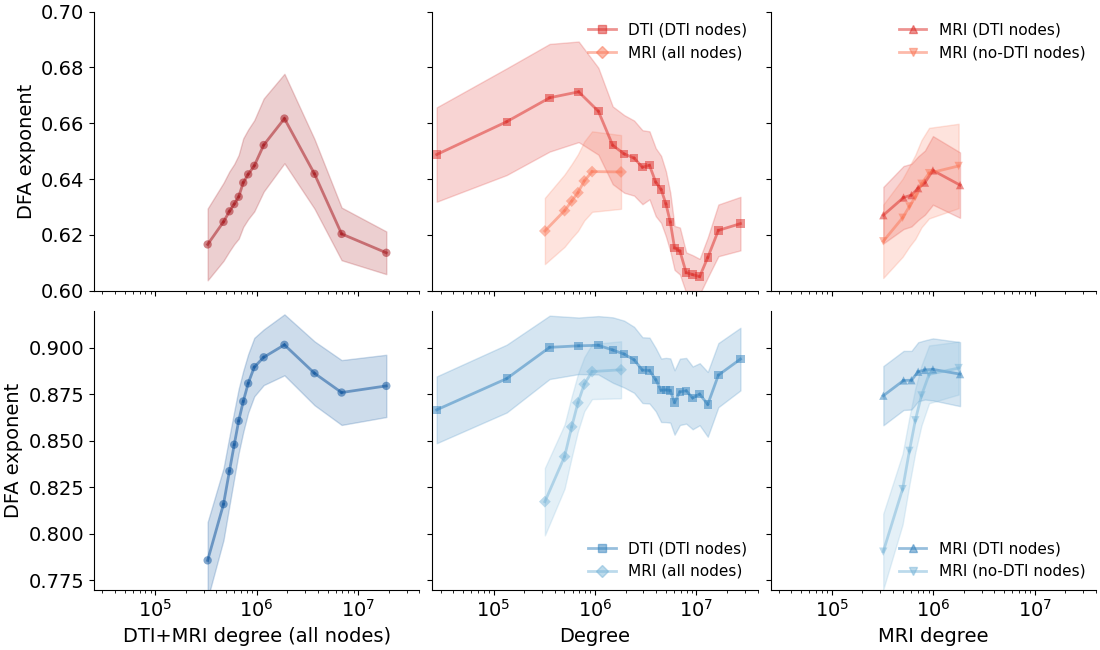

In [250]:
plt.close('all')

import cmasher as cmr
from matplotlib.ticker import FuncFormatter

# ── Configuration ──────────────────────────────────────────────────────
# Two conditions, one per row:
#   row 0: excitatory alpha     (red family)
#   row 1: inhibitory infraslow (blue family)
#
# Three columns, each row identical in structure:
#   col 0: DTI+MRI degree (all nodes)               — 1 curve
#   col 1: DTI degree (DTI nodes) + MRI degree (all nodes)
#   col 2: MRI degree (DTI nodes) + MRI degree (no-DTI nodes)
#
# Within a multi-curve panel, darker shade = curve with more structural
# information (more complete connectivity / restriction to DTI-bearing nodes).
#
# Marker shapes:
#   o (circle)        DTI+MRI combined
#   s (square)        DTI
#   D (diamond)       MRI on all nodes
#   ^ (up-triangle)   MRI on DTI nodes      ("has DTI")
#   v (down-triangle) MRI on no-DTI nodes   ("no DTI")

DEGREES_BASE_PATH = '/Users/marcoaqil/Desktop/miami_mac/Downloads'
DFA_BASE_PATH = '/Users/marcoaqil/Desktop/miami_mac/Graph-Stochastic-Wilson-Cowan-Model/test'

subject_ids = ['100307', '102816', '133019', '149741', '153732', '154532']

reds_subcmap  = plt.get_cmap(cmr.get_sub_cmap('Reds',  0.2, 0.95))
blues_subcmap = plt.get_cmap(cmr.get_sub_cmap('Blues', 0.2, 0.95))

# Sampling positions in the subcolormap (0 = light end, 1 = dark end)
SHADE_FULL  = 0.90  # combined DTI+MRI         — col 0
SHADE_DARK  = 0.65  # more-informative curve   — col 1/2 (DTI; MRI on DTI nodes)
SHADE_LIGHT = 0.35  # less-informative curve   — col 1/2 (MRI all; MRI no-DTI nodes)


def log_fmt(x, pos):
    """Tick formatter: render decade ticks as 10^n with proper minus sign."""
    exponent_int = int(np.round(np.log10(x)))
    if exponent_int < 0:
        return r'$10^{{\text{{-}}{}}}$'.format(abs(exponent_int))
    return r'$10^{{{}}}$'.format(exponent_int)


def load_concatenated_across_subjects(filename_template):
    """
    Load a per-subject .npy for each subject_id and return:
      values_concatenated     : 1D array, all subjects concatenated
      subject_index_per_vertex: 1D int array, same length, giving subject index
    `filename_template` must contain a `{subject_id}` placeholder.
    """
    per_subject_arrays = [
        np.load(filename_template.format(subject_id=sid)) for sid in subject_ids
    ]
    subject_index_arrays = [
        np.full(len(arr), subject_index) for subject_index, arr in enumerate(per_subject_arrays)
    ]
    return np.concatenate(per_subject_arrays), np.concatenate(subject_index_arrays)


# ── Load degrees (shared across both rows) ─────────────────────────────
degrees_dti_only,    _ = load_concatenated_across_subjects(
    DEGREES_BASE_PATH + '/{subject_id}/vertex_degrees_dti_only.npy'
)
degrees_mri_only,    _ = load_concatenated_across_subjects(
    DEGREES_BASE_PATH + '/{subject_id}/vertex_degrees_mri_only.npy'
)
degrees_dti_plus_mri, subject_index_per_vertex = load_concatenated_across_subjects(
    DEGREES_BASE_PATH + '/{subject_id}/vertex_degrees.npy'
)

# Outlier trim on combined DTI+MRI degree (same criterion as previous cell)
overall_keep_mask = (
    (degrees_dti_plus_mri > np.nanquantile(degrees_dti_plus_mri, 0.001))
    & (degrees_dti_plus_mri < np.nanquantile(degrees_dti_plus_mri, 0.999))
)
degrees_dti_only         = degrees_dti_only[overall_keep_mask]
degrees_mri_only         = degrees_mri_only[overall_keep_mask]
degrees_dti_plus_mri     = degrees_dti_plus_mri[overall_keep_mask]
subject_index_per_vertex = subject_index_per_vertex[overall_keep_mask]

# Vertex-subset masks (operate in trimmed space)
mask_all_nodes = degrees_dti_only >= 0
mask_with_dti  = degrees_dti_only >  0
mask_no_dti    = degrees_dti_only == 0


# ── Row conditions: (band, population_label, color_subcmap, y_limits) ──
row_conditions = [
    ('alpha',     'E', reds_subcmap,  (0.60, 0.70)),
    ('infraslow', 'I', blues_subcmap, (0.77, 0.92)),
]


# ── Build figure ───────────────────────────────────────────────────────
figure_deg, axes_deg = plt.subplots(
    2, 3, figsize=(11, 6.5),
    sharex='all', sharey='row',
    layout='constrained',
)

for row_index, (band, population_label, color_subcmap, ylim_tuple) in enumerate(row_conditions):
    # Load DFA for this (band, population) and apply the same overall mask
    dfa_filename_template = (
        DFA_BASE_PATH
        + f'/DFAexp_{population_label}_{band}_hcpmeg_10min_20khzsim_'
        + 'fftfilterdown500hz_230sec_polyorder3_adaptaps_{subject_id}.npy'
    )
    dfa_concatenated, _ = load_concatenated_across_subjects(dfa_filename_template)
    dfa_concatenated = dfa_concatenated[overall_keep_mask]

    # Per-column list of curves to draw. Each curve:
    #   (degree_array, vertex_mask, color, marker, legend_label, x_axis_label)
    curve_specs_per_column = [
        # col 0 — single curve
        [
            (degrees_dti_plus_mri, mask_all_nodes,
             color_subcmap(SHADE_FULL), 'o', None,
             'DTI+MRI degree (all nodes)'),
        ],
        # col 1 — DTI vs MRI on broadest applicable node set
        [
            (degrees_dti_only, mask_with_dti,
             color_subcmap(SHADE_DARK),  's', 'DTI (DTI nodes)',
             'Degree'),
            (degrees_mri_only, mask_all_nodes,
             color_subcmap(SHADE_LIGHT), 'D', 'MRI (all nodes)',
             'Degree'),
        ],
        # col 2 — MRI on DTI-bearing vs DTI-lacking nodes
        [
            (degrees_mri_only, mask_with_dti,
             color_subcmap(SHADE_DARK),  '^', 'MRI (DTI nodes)',
             'MRI degree'),
            (degrees_mri_only, mask_no_dti,
             color_subcmap(SHADE_LIGHT), 'v', 'MRI (no-DTI nodes)',
             'MRI degree'),
        ],
    ]

    for column_index, curve_specs in enumerate(curve_specs_per_column):
        current_axis = axes_deg[row_index, column_index]

        for (degree_array, vertex_mask,
             curve_color, marker_symbol, legend_label, x_axis_label) in curve_specs:

            # Per-curve outlier trim on this specific degree array
            combined_mask = (
                vertex_mask
                & (degree_array > np.nanquantile(degree_array, 0.001))
                & (degree_array < np.nanquantile(degree_array, 0.999))
            )

            # Adaptive bin count: ~25 bins per 4 decades of log-degree range
            positive_degrees_in_mask = degree_array[combined_mask & (degree_array > 0)]
            log_decade_span = (
                np.log10(np.max(degree_array[combined_mask]))
                - np.log10(np.min(positive_degrees_in_mask))
            )
            number_of_bins = int(25 * log_decade_span / 4)

            add_binned_mean_line(
                current_axis,
                degree_array[combined_mask],
                dfa_concatenated[combined_mask],
                lw=2,
                bins=number_of_bins,
                subj_bins=number_of_bins,
                min_points_per_bin=10,
                min_subjects_per_bin=3,
                color=curve_color,
                marker=marker_symbol,    # <-- assumed passthrough to line plot
                label=legend_label,      # <-- assumed passthrough to line plot
                equal_count_bins=True,
                logx=True,
                subject_dot_size=8,
                min_alpha=0.5,
                max_alpha=0.5,
                subject_dot_alpha=0.1,
                subject_indices=subject_index_per_vertex[combined_mask],
            )

            # x-label is identical for both curves in a panel; setting twice is harmless
            current_axis.set_xlabel(x_axis_label)

        current_axis.set_xscale('log')
        current_axis.xaxis.set_major_formatter(FuncFormatter(log_fmt))
        current_axis.set_xlim(2.5e4, 4e7)
        current_axis.set_ylim(*ylim_tuple)

        # In-panel legend only when there is more than one curve to distinguish
        if len(curve_specs) > 1:
            current_axis.legend(
                frameon=False, fontsize=11, loc='best',
                handlelength=1.8, borderaxespad=0.3,
            )

    axes_deg[row_index, 0].set_ylabel('DFA exponent')

# Hide x-labels on top row (sharex hides tick labels, but xlabels stay unless cleared)
for column_index in range(3):
    axes_deg[0, column_index].set_xlabel('')

# figure_deg.savefig(
#     "DFAexp_vs_degrees_2x3_alphaE_infraslowI.pdf",
#     dpi=600, transparent=True,
# )

# plotly

In [ ]:
index=np.argsort(np.abs(Deg_dti_mri_distweights-0.3))[-1]
index=np.argmax(Deg_dti_mri_distweights)

In [ ]:
#dw hcp meg prop viz
dw_param_idx = 0

ampdw=better_result['x'][dw_param_idx]
adw=better_result['x'][dw_param_idx+14]
bdw=better_result['x'][dw_param_idx+18]
tdw=0.5*better_result['x'][dw_param_idx+8]**2

#6369,3573
u_0=np.zeros(len(eigenvalues))
u_0[3573]=1e-7
# t_gauss = 0.5 * 0.005**2

# u_0 = np.dot(np.dot(eigenvectors, np.dot(sp.sparse.diags(GraphKernel(eigenvalues,
#                                                                      t_gauss, type='Gaussian')).toarray(), 
#                                          eigenvectors.T)),u_0)

K__dw_gfdomain=GraphKernel(eigenvalues, tdw, type='Damped Wave', a=adw, b=bdw, c=0, prime=False)

K_dw = np.dot(eigenvectors, np.dot(sp.sparse.diags(K__dw_gfdomain).toarray(), eigenvectors.T))

u_prop = ampdw*np.dot(K_dw,u_0)

In [ ]:
import numpy as np
import nibabel as nib
import plotly.graph_objs as go
import plotly.io as pio
import os

# ============================================================
# Dependencies: pip install kaleido for PDF export
# ============================================================

# --- Configuration -----------------------------------------------------------

subject_ids = ['100307', '102816', '133019', '149741', '153732', '154532']

band_configurations = {
    'alpha_excitatory': {
        'excitatory_or_inhibitory': 'E',
        'band_name': 'alpha',
        'colorscale': 'plasma',
        'label': 'DFA Exponent (Excitatory, Alpha)',
    },
    'infraslow_inhibitory': {
        'excitatory_or_inhibitory': 'I',
        'band_name': 'infraslow',
        'colorscale': 'plasma',
        'label': 'DFA Exponent (Inhibitory, Infraslow)',
    },
}

base_data_directory = "/Users/marcoaqil/Desktop/miami_mac/Downloads"

output_directory = "brain_dfa_pdfs"
os.makedirs(output_directory, exist_ok=True)

# --- Pre-pass: compute per-band colorbar range across all subjects -----------
# Pool all DFA exponents per band, then take quantile 0.1 / 0.9 of positive values

colorbar_ranges = {}
for band_key, band_config in band_configurations.items():
    all_positive_dfa_values = []
    for subject_id in subject_ids:
        dfa_filename = (
            f"DFAexp_{band_config['excitatory_or_inhibitory']}_{band_config['band_name']}"
            f"_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{subject_id}.npy"
        )
        dfa_values = np.load(dfa_filename)
        all_positive_dfa_values.append(dfa_values[dfa_values > 0])

    pooled_positive_dfa = np.concatenate(all_positive_dfa_values)
    colorbar_ranges[band_key] = (
        np.nanquantile(pooled_positive_dfa, 0.1),
        np.nanquantile(pooled_positive_dfa, 0.9),
    )
    print(f"Colorbar range for {band_key}: {colorbar_ranges[band_key]}")

# --- Camera views ------------------------------------------------------------
# Each entry: (view_name, hemispheres_to_show, camera_eye, figure_width, figure_height)
# hemispheres_to_show: 'left', 'right', or 'both'

camera_views = [
   ('right_posterior_medial',   'right',  dict(x=-0.8, y=-1.4,    z=0.0),  1200, 700),
    ('left_posterior_lateral',   'left',  dict(x=-0.8, y=-1.4,    z=0.0),  1200, 700),
    ('left_medial',    'left',  dict(x=1.5,  y=0,    z=0.0),  1100, 700),
    ('left_lateral',   'left',  dict(x=-1.5, y=0,    z=0.0),  1100, 700),
    ('right_medial',   'right', dict(x=-1.5, y=0,    z=0.0),  1100, 700),
    ('right_lateral',  'right', dict(x=1.5,  y=0,    z=0.0),  1100, 700),
   ('posterior',       'both',  dict(x=0,    y=-1.5, z=0.0),  1400, 700),
    ('anterior',        'both',  dict(x=0,    y=1.5,  z=0.0),  1400, 700),
    ('dorsal',          'both',  dict(x=0,    y=0,    z=1.5),  1400, 700),
]

# --- Helper functions --------------------------------------------------------

def compute_mean_curvature(vertices, faces):
    """Mean curvature via discrete Laplacian: H ≈ |Δx| / 2"""
    from cortex import polyutils

    surface = polyutils.Surface(vertices, faces)

    #curv = surface.smooth(surface.mean_curvature(), 10)
    raw_curvature = surface.mean_curvature()
    raw_curvature[np.isnan(raw_curvature)] = 0
    smoothed_curvature = surface.smooth(raw_curvature, 5)

    # Min-max normalize to [0, 1]
    normalized_curvature = (
        (smoothed_curvature - smoothed_curvature.min())
        / (smoothed_curvature.max() - smoothed_curvature.min())
    )
    return normalized_curvature


def load_hemisphere_data(subject_id, hemisphere_label):
    """
    Load surface geometry, curvature, and noncortical mask for one hemisphere.
    hemisphere_label: 'L' or 'R'
    """
    noncortical_mask_side = 'left' if hemisphere_label == 'L' else 'right'

    surface_gifti = nib.load(
        f"{base_data_directory}/{subject_id}/T1w/Native/"
        f"{subject_id}.{hemisphere_label}.midthickness.downsampled.surf.gii"
    )
    vertices = surface_gifti.darrays[0].data
    faces = surface_gifti.darrays[1].data

    curvature = compute_mean_curvature(vertices, faces)

    noncortical_mask_file = np.load(
        f"{base_data_directory}/{subject_id}/T1w/noncortical_vertex_mask.npz"
    )
    noncortical_mask = noncortical_mask_file[f"is_noncortical_{noncortical_mask_side}"]

    return vertices, faces, curvature, noncortical_mask


def build_curvature_underlay_trace(vertices, faces, curvature):
    """Grey curvature mesh shown beneath the data overlay."""
    return go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        lighting=dict(ambient=1, diffuse=0.1, roughness=0.9, specular=1.8, fresnel=0.01),
        colorscale='greys',
        intensity=curvature,
        showscale=False,
        opacity=1,
    )


def build_data_overlay_trace(vertices, faces, noncortical_mask, intensity_values,
                             colorscale, colorbar_min, colorbar_max,
                             show_colorbar, colorbar_title):
    """
    Colored data mesh, restricted to cortical triangles only.
    Only the last overlay trace in a figure should have show_colorbar=True.
    """
    triangles_vertex_i = faces[:, 0]
    triangles_vertex_j = faces[:, 1]
    triangles_vertex_k = faces[:, 2]

    cortical_triangles_mask = (
        ~noncortical_mask[triangles_vertex_i]
        & ~noncortical_mask[triangles_vertex_j]
        & ~noncortical_mask[triangles_vertex_k]
    )

    above_threshold_mask = (intensity_values > 0.56)

    cortical_triangles_mask &= (
        above_threshold_mask[triangles_vertex_i]
        & above_threshold_mask[triangles_vertex_j]
        & above_threshold_mask[triangles_vertex_k]
    )

    colorbar_config = None
    if show_colorbar:
        colorbar_config = dict(
            title=dict(text=colorbar_title, side='right'),
            len=0.6,
            thickness=15,
        )

    return go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=triangles_vertex_i[cortical_triangles_mask],
        j=triangles_vertex_j[cortical_triangles_mask],
        k=triangles_vertex_k[cortical_triangles_mask],
        lighting=dict(ambient=1, diffuse=0.1, roughness=0.9, specular=1.8, fresnel=0.01),
        cmin=np.nanquantile(intensity_values[above_threshold_mask],0.1),
        cmax=np.nanquantile(intensity_values[above_threshold_mask],0.9),
        intensity=intensity_values,
        colorscale=colorscale,
        showscale=show_colorbar,
        colorbar=colorbar_config,
        opacity=1,
    )


def build_layout(camera_eye, figure_width, figure_height):
    """Build a clean 3D layout with no axes/grid."""
    hidden_axis = dict(
        showbackground=False,
        showline=False,
        zeroline=False,
        showgrid=False,
        showticklabels=False,
        title='',
    )

    return go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(hidden_axis),
            yaxis=dict(hidden_axis),
            zaxis=dict(hidden_axis),
            camera=dict(
                up=dict(x=0, y=0, z=1),
                center=dict(x=0, y=0, z=0),
                eye=camera_eye,
            ),
        ),
        hovermode=False,
        autosize=True,
        width=figure_width,
        height=figure_height,
    )


# --- Main rendering loop ----------------------------------------------------

for subject_id in subject_ids:
    print(f"\n=== Subject {subject_id} ===")

    # Load both hemispheres
    left_vertices, left_faces, left_curvature, left_noncortical_mask = \
        load_hemisphere_data(subject_id, 'L')
    right_vertices, right_faces, right_curvature, right_noncortical_mask = \
        load_hemisphere_data(subject_id, 'R')

    num_left_vertices = len(left_curvature)

    for band_key, band_config in band_configurations.items():
        print(f"  Band: {band_key}")

        # Load DFA exponents (concatenated LH + RH)
        dfa_exponents_filename = (
            f"DFAexp_{band_config['excitatory_or_inhibitory']}_{band_config['band_name']}"
            f"_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{subject_id}.npy"
        )
        dfa_exponents = np.load(dfa_exponents_filename)

        left_dfa_exponents = dfa_exponents[:num_left_vertices]
        right_dfa_exponents = dfa_exponents[num_left_vertices:]

        band_colorbar_min, band_colorbar_max = colorbar_ranges[band_key]

        for view_name, hemispheres_to_show, camera_eye, fig_width, fig_height in camera_views:

            traces = []

            # --- Left hemisphere traces ---
            if hemispheres_to_show in ('left', 'both'):
                traces.append(
                    build_curvature_underlay_trace(left_vertices, left_faces, left_curvature)
                )
                # Show colorbar only on the last overlay added
                left_gets_colorbar = (hemispheres_to_show == 'left')
                traces.append(
                    build_data_overlay_trace(
                        left_vertices, left_faces, left_noncortical_mask,
                        left_dfa_exponents,
                        colorscale=band_config['colorscale'],
                        colorbar_min=band_colorbar_min,
                        colorbar_max=band_colorbar_max,
                        show_colorbar=left_gets_colorbar,
                        colorbar_title=band_config['label'],
                    )
                )

            # --- Right hemisphere traces ---
            if hemispheres_to_show in ('right', 'both'):
                traces.append(
                    build_curvature_underlay_trace(right_vertices, right_faces, right_curvature)
                )
                # For 'both', colorbar goes on the right hemisphere (last overlay)
                right_gets_colorbar = (hemispheres_to_show in ('right', 'both'))
                traces.append(
                    build_data_overlay_trace(
                        right_vertices, right_faces, right_noncortical_mask,
                        right_dfa_exponents,
                        colorscale=band_config['colorscale'],
                        colorbar_min=band_colorbar_min,
                        colorbar_max=band_colorbar_max,
                        show_colorbar=right_gets_colorbar,
                        colorbar_title=band_config['label'],
                    )
                )

            layout = build_layout(camera_eye, fig_width, fig_height)
            figure = go.Figure(data=traces, layout=layout)

            output_filename = f"{output_directory}/{subject_id}_{band_key}_{view_name}.pdf"
            pio.write_image(figure, output_filename, format='pdf')
            print(f"    Saved: {output_filename}")

print("\nDone.")

In [426]:
import numpy as np
import nibabel as nib
import plotly.graph_objs as go
import plotly.io as pio
from scipy.spatial import cKDTree
import os

# ============================================================
# Dependencies: pip install kaleido for PDF export
# ============================================================

# --- Configuration -----------------------------------------------------------

subject_ids = ['100307', '102816', '133019', '149741', '153732', '154532']

# Subject whose fs_LR 32k surface is used for plotting the average
plotting_subject_id = '100307'

# Surface type for plotting: 'midthickness', 'inflated', or 'very_inflated'
# Only affects visualization, not the resampling (which always uses midthickness)
plotting_surface_type = 'inflated'

band_configurations = {
    # 'alpha_excitatory': {
    #     'excitatory_or_inhibitory': 'E',
    #     'band_name': 'alpha',
    #     'colorscale': 'viridis',
    #     'label': 'DFA Exponent (Excitatory, Alpha)',
    #     'filepath_template': 'DFAexp_E_alpha_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{subject_id}.npy',
    # },
    # 'infraslow_inhibitory': {
    #     'excitatory_or_inhibitory': 'I',
    #     'band_name': 'infraslow',
    #     'colorscale': 'viridis',
    #     'label': 'DFA Exponent (Inhibitory, Infraslow)',
    #     'filepath_template': 'DFAexp_I_infraslow_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{subject_id}.npy',
    # },
    'vertex_degrees_dti': {
        'colorscale': 'plasma',
        'label': 'Vertex Degree (DTI only)',
        'filepath_template': '{base_data_directory}/{subject_id}/vertex_degrees_dti_only.npy',
    },
    'vertex_degrees_mri': {
        'colorscale': 'plasma',
        'label': 'Vertex Degree (MRI only)',
        'filepath_template': '{base_data_directory}/{subject_id}/vertex_degrees_mri_only.npy',
    },
    'vertex_degrees_dti_mri': {
        'colorscale': 'plasma',
        'label': 'Vertex Degree (DTI + MRI)',
        'filepath_template': '{base_data_directory}/{subject_id}/vertex_degrees.npy',
    },
}

base_data_directory = "/Users/marcoaqil/Desktop/miami_mac/Downloads"

output_directory = "brain_dfa_pdfs"
os.makedirs(output_directory, exist_ok=True)


# --- Resampling functions ----------------------------------------------------

def compute_resampling_indices(subject_id):
    """
    Compute nearest-neighbor index mapping from downsampled native midthickness
    to fs_LR 32k for both hemispheres. Built once per subject, reused for all
    data arrays and the noncortical mask.

    Returns
    -------
    left_resampling_indices : np.ndarray, shape (32492,)
        For each fs_LR 32k left vertex, the index of its nearest downsampled vertex.
    right_resampling_indices : np.ndarray, shape (32492,)
        Same for right hemisphere.
    num_left_downsampled_vertices : int
        Number of vertices in the left downsampled surface (split point for
        concatenated L+R arrays).
    """
    subject_directory = os.path.join(base_data_directory, subject_id)
    native_directory = os.path.join(subject_directory, 'T1w', 'Native')
    fsLR32k_directory = os.path.join(subject_directory, 'T1w', 'fsaverage_LR32k')

    resampling_indices = {}
    num_left_downsampled_vertices = None

    for hemisphere in ('L', 'R'):
        downsampled_surface = nib.load(os.path.join(
            native_directory,
            f'{subject_id}.{hemisphere}.midthickness.downsampled.surf.gii'
        ))
        fsLR32k_surface = nib.load(os.path.join(
            fsLR32k_directory,
            f'{subject_id}.{hemisphere}.midthickness_MSMAll.32k_fs_LR.surf.gii'
        ))

        downsampled_coordinates = downsampled_surface.darrays[0].data
        fsLR32k_coordinates = fsLR32k_surface.darrays[0].data

        source_kdtree = cKDTree(downsampled_coordinates)
        _, nearest_indices = source_kdtree.query(fsLR32k_coordinates)

        resampling_indices[hemisphere] = nearest_indices

        if hemisphere == 'L':
            num_left_downsampled_vertices = len(downsampled_coordinates)

    return resampling_indices['L'], resampling_indices['R'], num_left_downsampled_vertices


def resample_to_fsLR32k(data_both_hemispheres, left_resampling_indices,
                        right_resampling_indices, num_left_downsampled_vertices):
    """
    Apply precomputed nearest-neighbor mapping to resample a concatenated L+R
    array from downsampled native to fs_LR 32k.

    Parameters
    ----------
    data_both_hemispheres : np.ndarray, shape (num_downsampled_total,) or (num_downsampled_total, ...)
        Data on the downsampled native surface, left hemisphere first.
    left_resampling_indices, right_resampling_indices : np.ndarray
        From compute_resampling_indices.
    num_left_downsampled_vertices : int
        Split point between L and R in the concatenated array.

    Returns
    -------
    resampled_data : np.ndarray, shape (64984,) or (64984, ...)
    """
    left_data = data_both_hemispheres[:num_left_downsampled_vertices]
    right_data = data_both_hemispheres[num_left_downsampled_vertices:]

    left_resampled = left_data[left_resampling_indices]
    right_resampled = right_data[right_resampling_indices]

    return np.concatenate([left_resampled, right_resampled], axis=0)


# --- Helper functions --------------------------------------------------------

def compute_mean_curvature(vertices, faces):
    """Mean curvature via discrete Laplacian, smoothed and normalized to [0, 1]."""
    from cortex import polyutils

    surface = polyutils.Surface(vertices, faces)
    raw_curvature = surface.mean_curvature()
    raw_curvature[np.isnan(raw_curvature)] = 0
    smoothed_curvature = surface.smooth(raw_curvature, 5)

    normalized_curvature = (
        (smoothed_curvature - smoothed_curvature.min())
        / (smoothed_curvature.max() - smoothed_curvature.min())
    )
    return normalized_curvature


def load_hemisphere_fsLR32k(subject_id, hemisphere_label, surface_type='midthickness'):
    """
    Load fs_LR 32k surface geometry and curvature for one hemisphere.
    hemisphere_label: 'L' or 'R'
    surface_type: 'midthickness', 'inflated', or 'very_inflated'
    """
    surface_gifti = nib.load(
        f"{base_data_directory}/{subject_id}/T1w/fsaverage_LR32k/"
        f"{subject_id}.{hemisphere_label}.{surface_type}_MSMAll.32k_fs_LR.surf.gii"
    )
    vertices = surface_gifti.darrays[0].data
    faces = surface_gifti.darrays[1].data
    curvature = compute_mean_curvature(vertices, faces)

    return vertices, faces, curvature


def build_curvature_underlay_trace(vertices, faces, curvature):
    """Grey curvature mesh shown beneath the data overlay."""
    return go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        lighting=dict(ambient=1, diffuse=0.1, roughness=0.9, specular=1.8, fresnel=0.01),
        colorscale='greys',
        intensity=curvature,
        showscale=False,
        opacity=1,
    )


def build_data_overlay_trace(vertices, faces, noncortical_mask, intensity_values,
                             colorscale, colorbar_min, colorbar_max,
                             show_colorbar, colorbar_title):
    """
    Colored data mesh, restricted to cortical triangles only.
    Triangles touching any noncortical vertex or any vertex below threshold are hidden.
    Only the last overlay trace in a figure should have show_colorbar=True.
    """
    triangles_vertex_i = faces[:, 0]
    triangles_vertex_j = faces[:, 1]
    triangles_vertex_k = faces[:, 2]

    # Exclude triangles touching noncortical vertices
    cortical_triangles_mask = (
        ~noncortical_mask[triangles_vertex_i]
        & ~noncortical_mask[triangles_vertex_j]
        & ~noncortical_mask[triangles_vertex_k]
    )

    # Exclude triangles below data threshold
    # above_threshold_mask = (intensity_values > 0.56)
    # cortical_triangles_mask &= (
    #     above_threshold_mask[triangles_vertex_i]
    #     & above_threshold_mask[triangles_vertex_j]
    #     & above_threshold_mask[triangles_vertex_k]
    # )

    colorbar_config = None
    if show_colorbar:
        colorbar_config = dict(
            title=dict(text=colorbar_title, side='right'),
            len=0.6,
            thickness=15,
        )

    return go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=triangles_vertex_i[cortical_triangles_mask],
        j=triangles_vertex_j[cortical_triangles_mask],
        k=triangles_vertex_k[cortical_triangles_mask],
        lighting=dict(ambient=1, diffuse=0.1, roughness=0.9, specular=1.8, fresnel=0.01),
        cmin=colorbar_min,
        cmax=colorbar_max,
        intensity=intensity_values,
        colorscale=colorscale,
        showscale=show_colorbar,
        colorbar=colorbar_config,
        opacity=1,
    )


def build_layout(camera_eye, figure_width, figure_height):
    """Build a clean 3D layout with no axes/grid."""
    hidden_axis = dict(
        showbackground=False,
        showline=False,
        zeroline=False,
        showgrid=False,
        showticklabels=False,
        title='',
    )

    return go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(hidden_axis),
            yaxis=dict(hidden_axis),
            zaxis=dict(hidden_axis),
            camera=dict(
                up=dict(x=0, y=0, z=1),
                center=dict(x=0, y=0, z=0),
                eye=camera_eye,
            ),
        ),
        hovermode=False,
        autosize=True,
        width=figure_width,
        height=figure_height,
    )


# --- Camera views ------------------------------------------------------------

camera_views = [
    ('left_lateral_slightpost',          'left',  dict(x=-1.4, y=-0.6,    z=0.0), 1100, 700),
    ('right_lateral_slightpost',         'right', dict(x=1.4,  y=-0.6,    z=0.0), 1100, 700),
    # ('right_posterior_medial', 'right', dict(x=-0.8, y=-1.4, z=0.0), 1200, 700),
    # ('left_posterior_lateral', 'left',  dict(x=-0.8, y=-1.4, z=0.0), 1200, 700),
     ('left_medial',           'left',  dict(x=1.5,  y=-0.2,    z=0.0), 1100, 700),
    # ('left_lateral',          'left',  dict(x=-1.5, y=0,    z=0.0), 1100, 700),
     ('right_medial',          'right', dict(x=-1.5, y=-0.2,    z=0.0), 1100, 700),
    # ('right_lateral',         'right', dict(x=1.5,  y=0,    z=0.0), 1100, 700),
    # ('posterior',             'both',  dict(x=0,    y=-1.5, z=0.0), 1400, 700),
    # ('anterior',              'both',  dict(x=0,    y=1.5,  z=0.0), 1400, 700),
    # ('dorsal',                'both',  dict(x=0,    y=0,    z=1.5), 1400, 700),
]


# =============================================================================
# Step 1: Resample each subject's data + noncortical mask to fs_LR 32k
# =============================================================================

print("=== Step 1: Resample individual subjects to fs_LR 32k ===\n")

resampled_data_per_band = {band_key: [] for band_key in band_configurations}
resampled_noncortical_masks = []

for subject_id in subject_ids:
    print(f"Subject {subject_id}:")

    # Compute resampling indices once per subject
    left_indices, right_indices, num_left_downsampled = compute_resampling_indices(subject_id)

    # Resample noncortical mask (stored as separate L/R in .npz)
    noncortical_mask_file = np.load(
        f"{base_data_directory}/{subject_id}/T1w/noncortical_vertex_mask.npz"
    )
    noncortical_mask_combined = np.concatenate([
        noncortical_mask_file['is_noncortical_left'],
        noncortical_mask_file['is_noncortical_right'],
    ])
    noncortical_mask_fsLR32k = resample_to_fsLR32k(
        noncortical_mask_combined.astype(np.float32),
        left_indices, right_indices, num_left_downsampled
    ) > 0.5  # Back to boolean after nearest-neighbor
    resampled_noncortical_masks.append(noncortical_mask_fsLR32k)
    print(f"  Noncortical mask: {noncortical_mask_fsLR32k.sum()} vertices marked")

    # Resample DFA data for each band
    for band_key, band_config in band_configurations.items():
        data_filepath = band_config['filepath_template'].format(
            subject_id=subject_id,
            base_data_directory=base_data_directory,
        )
        dfa_data = np.load(data_filepath)

        resampled_data = resample_to_fsLR32k(
            dfa_data, left_indices, right_indices, num_left_downsampled
        )

        # Save with _fslr32k suffix
        output_path = data_filepath.replace('.npy', '_fslr32k.npy')
        np.save(output_path, resampled_data)
        print(f"  Saved: {output_path}, shape: {resampled_data.shape}")

        resampled_data_per_band[band_key].append(resampled_data)

# Union of noncortical masks: vertex is noncortical if noncortical in ANY subject
noncortical_mask_union = np.all(np.stack(resampled_noncortical_masks, axis=0), axis=0)
print(f"\nUnion noncortical mask: {noncortical_mask_union.sum()} / {len(noncortical_mask_union)} vertices")

# =============================================================================
# Step 2: Average across subjects in fs_LR 32k space
# =============================================================================

print("\n=== Step 2: Average across subjects ===\n")

average_dfa_per_band = {}
for band_key, resampled_list in resampled_data_per_band.items():
    stacked_subjects = np.stack(resampled_list, axis=0)
    average_dfa_per_band[band_key] = np.nanmean(stacked_subjects, axis=0)
    print(f"{band_key}: averaged {len(resampled_list)} subjects, "
          f"shape {average_dfa_per_band[band_key].shape}")

# =============================================================================
# Step 3: Compute colorbar ranges from the averaged data
# =============================================================================

colorbar_ranges = {}
for band_key, average_dfa in average_dfa_per_band.items():
    # if band_key == 'infraslow_inhibitory':
    #     colorbar_ranges[band_key] = (0.8,0.9)
    # elif band_key == 'alpha_excitatory':
    #     colorbar_ranges[band_key] = (0.6,0.7)
    # else:

    colorbar_ranges[band_key] = (
        np.nanquantile(average_dfa, 0.1),
        np.nanquantile(average_dfa, 0.9),
    )
    print(f"Colorbar range for {band_key}: {colorbar_ranges[band_key]}")

# =============================================================================
# Step 4: Load plotting surface (fs_LR 32k for the chosen subject)
# =============================================================================

print(f"\n=== Step 4: Loading plotting surface from subject {plotting_subject_id} ===\n")

left_vertices, left_faces, left_curvature = load_hemisphere_fsLR32k(plotting_subject_id, 'L', plotting_surface_type)
right_vertices, right_faces, right_curvature = load_hemisphere_fsLR32k(plotting_subject_id, 'R', plotting_surface_type)

num_left_fsLR32k_vertices = len(left_vertices)

# Split the union noncortical mask into hemispheres
left_noncortical_mask = noncortical_mask_union[:num_left_fsLR32k_vertices]
right_noncortical_mask = noncortical_mask_union[num_left_fsLR32k_vertices:]

print(f"Left hemisphere: {num_left_fsLR32k_vertices} vertices, {len(left_faces)} faces")
print(f"Right hemisphere: {len(right_vertices)} vertices, {len(right_faces)} faces")

# =============================================================================
# Step 5: Render and save average brain maps
# =============================================================================

print(f"\n=== Step 5: Rendering average maps ===\n")

for band_key, band_config in band_configurations.items():
    print(f"Band: {band_key}")

    average_dfa = average_dfa_per_band[band_key]
    left_dfa_average = average_dfa[:num_left_fsLR32k_vertices]
    right_dfa_average = average_dfa[num_left_fsLR32k_vertices:]

    band_colorbar_min, band_colorbar_max = colorbar_ranges[band_key]

    for view_name, hemispheres_to_show, camera_eye, fig_width, fig_height in camera_views:

        traces = []

        # --- Left hemisphere traces ---
        if hemispheres_to_show in ('left', 'both'):
            traces.append(
                build_curvature_underlay_trace(left_vertices, left_faces, left_curvature)
            )
            left_gets_colorbar = (hemispheres_to_show == 'left')
            traces.append(
                build_data_overlay_trace(
                    left_vertices, left_faces, left_noncortical_mask,
                    left_dfa_average,
                    colorscale=band_config['colorscale'],
                    colorbar_min=band_colorbar_min,
                    colorbar_max=band_colorbar_max,
                    show_colorbar=left_gets_colorbar,
                    colorbar_title=band_config['label'],
                )
            )

        # --- Right hemisphere traces ---
        if hemispheres_to_show in ('right', 'both'):
            traces.append(
                build_curvature_underlay_trace(right_vertices, right_faces, right_curvature)
            )
            right_gets_colorbar = (hemispheres_to_show in ('right', 'both'))
            traces.append(
                build_data_overlay_trace(
                    right_vertices, right_faces, right_noncortical_mask,
                    right_dfa_average,
                    colorscale=band_config['colorscale'],
                    colorbar_min=band_colorbar_min,
                    colorbar_max=band_colorbar_max,
                    show_colorbar=right_gets_colorbar,
                    colorbar_title=band_config['label'],
                )
            )

        layout = build_layout(camera_eye, fig_width, fig_height)
        figure = go.Figure(data=traces, layout=layout)
        #figure.update_layout(paper_bgcolor='black')

        output_filename = f"{output_directory}/average_{band_key}_{view_name}_{plotting_surface_type}.pdf"
        pio.write_image(figure, output_filename, format='pdf')
        print(f"  Saved: {output_filename}")

print("\nDone.")

=== Step 1: Resample individual subjects to fs_LR 32k ===

Subject 100307:
  Noncortical mask: 4246 vertices marked
  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/100307/vertex_degrees_dti_only_fslr32k.npy, shape: (64984,)
  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/100307/vertex_degrees_mri_only_fslr32k.npy, shape: (64984,)
  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/100307/vertex_degrees_fslr32k.npy, shape: (64984,)
Subject 102816:
  Noncortical mask: 4456 vertices marked
  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/102816/vertex_degrees_dti_only_fslr32k.npy, shape: (64984,)
  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/102816/vertex_degrees_mri_only_fslr32k.npy, shape: (64984,)
  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/102816/vertex_degrees_fslr32k.npy, shape: (64984,)
Subject 133019:
  Noncortical mask: 3983 vertices marked
  Saved: /Users/marcoaqil/Desktop/miami_mac/Downloads/133019/vertex_degrees_dti_only_fslr32k.npy, shape:

/Users/marcoaqil/miniforge3/envs/gnf_env/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


Left hemisphere: 32492 vertices, 64980 faces
Right hemisphere: 32492 vertices, 64980 faces

=== Step 5: Rendering average maps ===

Band: vertex_degrees_dti
  Saved: brain_dfa_pdfs/average_vertex_degrees_dti_left_lateral_slightpost_inflated.pdf
  Saved: brain_dfa_pdfs/average_vertex_degrees_dti_right_lateral_slightpost_inflated.pdf
  Saved: brain_dfa_pdfs/average_vertex_degrees_dti_left_medial_inflated.pdf
  Saved: brain_dfa_pdfs/average_vertex_degrees_dti_right_medial_inflated.pdf
Band: vertex_degrees_mri
  Saved: brain_dfa_pdfs/average_vertex_degrees_mri_left_lateral_slightpost_inflated.pdf
  Saved: brain_dfa_pdfs/average_vertex_degrees_mri_right_lateral_slightpost_inflated.pdf
  Saved: brain_dfa_pdfs/average_vertex_degrees_mri_left_medial_inflated.pdf
  Saved: brain_dfa_pdfs/average_vertex_degrees_mri_right_medial_inflated.pdf
Band: vertex_degrees_dti_mri
  Saved: brain_dfa_pdfs/average_vertex_degrees_dti_mri_left_lateral_slightpost_inflated.pdf
  Saved: brain_dfa_pdfs/average_verte

In [ ]:
import plotly.offline as offline
from plotly.graph_objs import *
#init_notebook_mode(connected=True)
offline.init_notebook_mode()

#'100307', '102816', '133019', '149741', '153732', '154532'

sjnr = '100307'

import nibabel as nib

def compute_mean_curvature(vertices, faces):
    """Mean curvature via discrete Laplacian: H ≈ |Δx| / 2"""
    from cortex import polyutils

    surf = polyutils.Surface(vertices, faces)

    #curv = surf.smooth(surf.mean_curvature(), 10)
    curv = surf.mean_curvature()
    curv[np.isnan(curv)] = 0
    curv_smooth = surf.smooth(curv, 5)

    curv_smooth = (curv_smooth - curv_smooth.min())/(curv_smooth.max()-curv_smooth.min())
    return curv_smooth

# Usage:
lh_surf = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/Native/{sjnr}.L.midthickness.downsampled.surf.gii")
rh_surf = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/Native/{sjnr}.R.midthickness.downsampled.surf.gii")

lh_curvature = compute_mean_curvature(lh_surf.darrays[0].data, lh_surf.darrays[1].data)
rh_curvature = compute_mean_curvature(rh_surf.darrays[0].data, rh_surf.darrays[1].data)
curvature = np.concatenate((lh_curvature,rh_curvature))


band = 'alpha'

excitatory_dfa = np.load(
            f'DFAexp_E_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{sjnr}.npy'
        )
inhibitory_dfa = np.load(
            f'DFAexp_I_{band}_hcpmeg_10min_20khzsim_fftfilterdown500hz_230sec_polyorder3_adaptaps_{sjnr}.npy'
        )

this_Deg_dti_distweights = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/vertex_degrees_dti_only.npy')
this_Deg_mri_distweights = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/vertex_degrees_mri_only.npy')
this_Deg_dti_mri_distweights = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/vertex_degrees.npy')

# cmin_value=0.5
# cmax_value=0.9np.dot(eigenvectors**2,JacEigs.real[:,0]) #-np.sum(eigenvectors[:,(JacEigs.real[:,0]>-1)], axis=1)


intensity_processed = np.dot(eigenvectors, 1/JacEigs.real[:,0])#edfa#np.dot(eigenvectors,damping)#-np.sum(eigenvectors[:,(beta_edfa>0.7)], axis=1)#np.array(alpha_power)[:len(lh_curvature)]# lh_curvature # np.clip(u_prop, cmin_value, cmax_value)


trace2=Mesh3d(x=lh_surf.darrays[0].data[:,0],
               y=lh_surf.darrays[0].data[:,1],
               z=lh_surf.darrays[0].data[:,2],
              i=lh_surf.darrays[1].data[:,0],
              j=lh_surf.darrays[1].data[:,1],
              k=lh_surf.darrays[1].data[:,2],
            #  text=np.arange(len(Xn)),
              #lighting used for images/old/NFsim plots, not for DWave
             lighting = dict(ambient=1, diffuse=0.1, roughness = 0.9, specular=1.8, fresnel=0.01),
              #colorlimits USE IF NEEDED (0.1 good for Dwave, 0.01 to show WMprop)(20 good for fmri demeaned)
            cmin=np.nanquantile(intensity_processed,0.1),#-0.7,#np.nanquantile(dfa_h_inhib_lowpass,0.05),#1e6,#0.5,#Ess-2*1e-7,#0.05,#,#20,#-10E-9,#-0.1,#-10E-9,#-0.1,
             cmax=np.nanquantile(intensity_processed,0.9),#0.3,#np.nanquantile(dfa_h_inhib_lowpass,0.95),#5e6,#0.6,#Ess+2*1e-7,#0.0501,#Ess+5*1e-7,#20, #10E-9#0.1#10E-9#0.1
              #eigenvectors[:,1001]#     
      #        cauto=False,
              
          #     mode='markers',
          #  marker=dict(
          #          size=5,
             
                    intensity=intensity_processed,#-u_0,#curv,#dfa_h_exc_lowpass,#curv,#np.load('/data1/projects/dumoulinlab/Lab_members/Marco/images/old/NFsim/DFAexp_812alpha_125sec.npy'),#np.sqrt(AllVet[2,:]**2+AllVet[0,:]**2+AllVet[1,:]**2),                # set color to an array/list of desired values
                    colorscale='plasma',#'greys',   # choose a colorscale
              showscale=False,
                    opacity=1#0.3
          #          line=dict(color='rgba(0, 0, 0,0.5)',
          #                     width=1,
        #                     )
        #                )
              #flatshading=True,
                )
data = [trace2]#[trace4,trace2,trace1,trace3]
axis=dict(showbackground=False,
          showline=False,
          zeroline=False,
          showgrid=False,
          showticklabels=False,
          title=''
          )
                 
layout = Layout(
    margin=dict(
        l=0,
        r=0,
        b=0,
        t=0
    ),
    scene=dict(
             xaxis=dict(axis),
             yaxis=dict(axis),
             zaxis=dict(axis),
        camera = dict(
   up=dict(x=0, y=0, z=1),
   center=dict(x=0, y=0.0, z=0),
    eye=dict(x=1.5, y=0, z=0.0)
)),  
    hovermode=False,   
    autosize=True,
    width=1100,
    height=700
)  
fig = Figure(data=data, layout=layout)

offline.iplot(fig)

In [ ]:
E_total = np.dot(eigenvectors,Beta_E_total)

In [ ]:
import plotly.offline as offline
from plotly.graph_objs import *
#init_notebook_mode(connected=True)
offline.init_notebook_mode()

#mesh (or full connectome) graph edges
#trace1=Scatter3d(x=Xe,
#               y=Ye,
#               z=Ze,
#               mode='lines',
#              line=Line(color='rgba(0,0,0,1)', width=1),
#             )




#Mesh3d
trace2=Mesh3d(x=lh_surf.darrays[0].data[:,0],
               y=lh_surf.darrays[0].data[:,1],
               z=lh_surf.darrays[0].data[:,2],
              i=lh_surf.darrays[1].data[:,0],
              j=lh_surf.darrays[1].data[:,1],
              k=lh_surf.darrays[1].data[:,2],
              #lighting used for images/old/NFsim plots, not for DWave
    flatshading=False,
    lighting=dict(
        ambient=0.5,
        diffuse=0.8,
        specular=0.3,
        roughness=0.5,
        fresnel=0.2
    ),
    lightposition=dict(x=100, y=200, z=0),
              #colorlimits USE IF NEEDED (0.1 good for Dwave, 0.01 to show WMprop)(20 good for fmri demeaned)
              cmin=2*1e-7,#-0.0005,#Ess-2*1e-7,#0.05,#,#20,#-10E-9,#-0.1,#-10E-9,#-0.1,
              cmax=5*1e-7,#0.0005,#Ess+2*1e-7,#0.0501,#Ess+5*1e-7,#20, #10E-9#0.1#10E-9#0.1
              #eigenvectors[:,1001]#
          #    flatshading=True,
              
            
              
          #     mode='markers',
          #  marker=dict(
          #          size=5,
          #          color=-AllVet[1,:],#np.sqrt(AllVet[2,:]**2+AllVet[0,:]**2+AllVet[1,:]**2),                # set color to an array/list of desired values
                    colorscale='viridis',#'RdBu_r',   # choose a colorscale
          #          opacity=0.8,
          #          line=dict(color='rgba(0, 0, 0,0.5)',
          #                     width=1,
        #                     )
        #                )
                )


###SET WHAT IS GONNA BE PLOTTED
interval = 1
start_time = 500
max_time = 800

#timecourse_demeaned = timecourse-timecourse.mean(1)[...,np.newaxis]
#np.sqrt(3.85007284e+18)*resamp_conn_activity[:,i]
#np.nan_to_num(sp.stats.zscore(timecourse, axis=1))[:,i]
#np.nan_to_num(sp.stats.zscore(resamp_conn_activity, axis=1))[:,i]

sim_path = f"sim/{sjnr}_short"
paths_E = natsorted(glob.glob(f'{sim_path}/beta_E_activity*.npz'))
eigenvectors = np.load(f'/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/eigenvectors.npy')

E_total = np.concatenate([eigenvectors @ np.load(paths_E[i])['arr_0'][:,::40] for i in range(2)], axis=-1)


frames =[dict(data=[dict(type='mesh3d', 
                         #HERE IS WHAT DECIDES THE COLOR-TIMEPLOT
                         intensity= E_total[:,i])],#u_total[:,i])],#eigenvectors[:,i]
                  traces=[0],
                  name='{}'.format(i)) for i in range(start_time,max_time,interval)] 



axis=dict(showbackground=False,
          showline=False,
          zeroline=False,
          showgrid=False,
          showticklabels=False,
          title=''
          )
                 
layout = Layout(
    margin=dict(
        l=0,
        r=0,
        b=0,
        t=0
    ),
    scene=dict(
             xaxis=dict(axis),
             yaxis=dict(axis),
             zaxis=dict(axis),
        camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
            #good left occipital love view eye=dict(x=-1, y=-1.25, z=0.9). view from top eye=dict(x=0, y=0, z=1.8)
    eye=dict(x=0, y=0, z=1.8)
)),  
    hovermode=False,     autosize=False,
    width=1400,
    height=1150
)       
data=[trace2]

fig_frames = Figure(data=data, layout=layout, frames=frames)

fig_frames['layout']['updatemenus'] = [
    {
        'buttons': [
            {
                'args': [None, {'frame': {'duration': 100, 'redraw': True},
                         'fromcurrent': True, 'transition': {'duration': 10, 'easing': 'quadratic-in-out'}}],
                'label': 'Play',
                'method': 'animate'
            },
            {
                'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate',
                'transition': {'duration': 0}}], 
                'label': 'Pause',
                'method': 'animate'
            }
        ],
        'direction': 'left',
        'pad': {'r': 10, 't': 87},
        'showactive': True,
        'type': 'buttons',
        'x': 0.1,
        'xanchor': 'right',
        'y': 0,
        'yanchor': 'top'
    }
]



fig_frames['layout']['sliders'] = [{
    'active': 0,
    'yanchor': 'top',
    'xanchor': 'left',
    'currentvalue': {
        'font': {'size': 20},
        'prefix': 'time=',
        'visible': True,
        'xanchor': 'right'
    },
    'transition': {'duration': 10, 'easing': 'cubic-in-out'},
    'pad': {'b': 10, 't': 5},
    'len': 0.9,
    'x': 0.1,
    'y': 0,
    'steps': [{
    'method': 'animate',
    'label': '{}'.format(i),
   # 'value': '',
    'args': [[i], {'frame': {'duration': 200, 'redraw': True},
         'mode': 'immediate'}
    ],
} for i in range(start_time,max_time,interval)]
}]



#fig=Figure(data=data, layout=layout)

offline.iplot(fig_frames, filename='Les-Miserables')

In [ ]:
Fibers = np.load('/data1/projects/dumoulinlab/Lab_members/Marco/NFsim/Fibers_myfix.npy',allow_pickle=True)

EX=[]
EY=[]
EZ=[]
colors=[]

counter=0
skipper=4

for i in range(0,len(Fibers),1):
    counter+=1
    for j in range(0, Fibers[i].shape[0]-skipper, skipper):
        EX+=[Fibers[i][j,0], Fibers[i][j+skipper,0], None]
        EY+=[Fibers[i][j,1], Fibers[i][j+skipper,1], None]
        EZ+=[Fibers[i][j,2], Fibers[i][j+skipper,2], None]
        colors+=[counter]

counter    


    

In [ ]:
def rescale(x):
    y = np.array(x)
    y[y==None] = 0
#     y -= y.mean()
#     y **= 2
    
#     y /= y.max()
        
    return y

In [ ]:
#color = rescale(EX)+rescale(EY)+rescale(EZ)

color = np.abs(rescale(EX))**0.5

In [ ]:
import plotly.offline as offline
from plotly.graph_objs import *
#init_notebook_mode(connected=True)
offline.init_notebook_mode()

trace3=Scatter3d(x=EX,
               y=EY,
               z=EZ,
               mode='lines',
                line=Line(color=[p if p is not None else 0 for p in color],#'rgba(100,100,100,0.9)',#colors
                          colorscale='PRGn',
#                          #colorscale=[[0, 'rgb(0,0,255)'], [1, 'rgb(255,0,0)']],#'Rainbow',
                          width=2)
               )
axis=dict(showbackground=False,
          showline=False,
          zeroline=False,
          showgrid=False,
          showticklabels=False,
          title=''
          )
layout = Layout(
    margin=dict(
        l=0,
        r=0,
        b=0,
        t=0
    ),
    scene=dict(
             xaxis=dict(axis),
             yaxis=dict(axis),
             zaxis=dict(axis),
        camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
            #good left occipital love view eye=dict(x=-1, y=-1.25, z=0.9). view from top eye=dict(x=0, y=0, z=1.8)
    eye=dict(x=2, y=0.8, z=0.7)
)),  
    hovermode=False,     autosize=True,
    width=1000,
    height=1150
)  
data=Data([trace3])
fig=Figure(data=data, layout=layout)

offline.iplot(fig, filename='Les-Miserables-2')